# Rezultatų vizualizacijos — Bakalauro darbo 4 skyrius

Šis notebookas generuoja **visus 4 skyriaus** („Rezultatai“) paveikslus ir lenteles iš `08_kbp_krp_grid_*.py` skriptų išvesties (`results/kbp_krp_grid_*.csv`).

Apima:

- **13 pav.** — PR-AUC paviršiai 2-D $(K_{\mathrm{BP}}, K_{\mathrm{RP}})$ tinklelyje (8 arba 12 skydelių).
- **6 lentelė** — geriausi (basis × classifier) deriniai.
- **14 pav.** — PR-AUC dėžučių grafikai 50 splitų.
- **7 lentelė** — porinis Wilcoxon ženkluotųjų rangų testas.
- **15 pav.** — jautrumas vs tikslumas su Ambrosch ir kt. (2026) palyginimu.
- **16 pav.** — Judeno ir F1 slenksčių palyginimas.
- **Suvestiniai skaičiai** — rašytojui skirta santrauka (tik spausdinama).

Stilius perimtas iš `thesis_figures/plot_style.py` (`COLORS`, `BASES_LT`, `apply_style`, `save_fig`). Paveikslai saugomi `figures/` kataloge kaip PNG (300 dpi) + SVG; jokie CSV ar tekstiniai failai neišsaugomi.

Po `Skyriaus 0` (`Load data`) **kiekvieną figūros / lentelės ląstelę galima paleisti savarankiškai** — visi tarpiniai dydžiai persikuria iš `df`.


## 0. Duomenų įkėlimas, stiliaus modulis, paruošimas

Iš `results/` įkeliami visi 12 grid CSV failų (4 klasifikatoriai × 3 bazės). Visi reikalingi stulpeliai tikrinami — jei trūksta, ląstelė nutraukiama su aiškia žinute. Plačios formos lentelėje kiekvienai $(basis, classifier, K_{\mathrm{BP}}, K_{\mathrm{RP}}, \text{split})$ ląstelei pridedami `*_youden` ir `*_f1` slenksčio metrikų sufiksai, kad abu operacijos taškai liktų prieinami po vieną.

Sąžiningas „smoke-test“ režimas: nustačius `SMOKE = True`, naudojamas tik LR klasifikatorius — visa logika praeina iki galo, tik figūros tampa mažesnės. Galutiniame paleidime `SMOKE = False`.


In [1]:
from __future__ import annotations

import sys
import warnings
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

NOTEBOOK_DIR = Path.cwd()
WORKSPACE_ROOT = NOTEBOOK_DIR.parent
RESULTS_DIR = NOTEBOOK_DIR / "results"
FIGURES_DIR = NOTEBOOK_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

THESIS_FIG_DIR = WORKSPACE_ROOT / "thesis_figures"
if str(THESIS_FIG_DIR) not in sys.path:
    sys.path.insert(0, str(THESIS_FIG_DIR))

import importlib
import plot_style
importlib.reload(plot_style)
ps = plot_style
ps.set_rc_defaults()

print("Stiliaus modulis :", ps.__file__)
print("Rezultatai       :", RESULTS_DIR)
print("Paveikslai       :", FIGURES_DIR)


Stiliaus modulis : /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/plot_style.py
Rezultatai       : /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/results
Paveikslai       : /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/figures


In [2]:
SMOKE = False  # True → tik LR klasifikatorius (greitas integralumo patikrinimas)

BASES = ("chebyshev", "legendre", "bspline")
CLASSIFIERS = ("LR", "RF", "SVM", "XGB")

BASES_LT = ps.BASES_LT
BASIS_SHORT = {"chebyshev": "\u010c", "legendre": "L", "bspline": "BS"}
BASIS_COLORS = {b: ps.COLORS[b] for b in BASES}

CLASSIFIERS_LT = {
    "LR":  "Logistin\u0117 regresija",
    "RF":  "Atsitiktinis mi\u0161kas",
    "SVM": "SVM",
    "XGB": "XGBoost",
}
# Trumpos etikets ank\u0161toms vietoms (a\u0161i\u0173 \u017eym\u0117s, d\u0117\u017eu\u010di\u0173 diagramos).
CLASSIFIERS_TICK = {
    "LR":  "LR",
    "RF":  "RF",
    "SVM": "SVM",
    "XGB": "XGBoost",
}
# Okabe-Ito spalva\u012f patikrinta paletė, atskirta nuo bazi\u0173 spalv\u0173
CLASSIFIER_COLORS = {
    "LR":  "#0072B2",
    "RF":  "#D55E00",
    "SVM": "#009E73",
    "XGB": "#CC79A7",
}
CLASSIFIER_MARKERS = {"LR": "o", "RF": "s", "SVM": "^", "XGB": "D"}

THRESH_COLORS = {"youden": ps.COLORS["single"], "f1": ps.COLORS["binary"]}
THRESH_LT = {"youden": "Judeno slenkstis (J)", "f1": "F1-optimuotas slenkstis"}

K_BP_LABEL = r"$K_{\mathrm{BP}}$"
K_RP_LABEL = r"$K_{\mathrm{RP}}$"
PR_AUC_LABEL = "PR-AUC"
ROC_AUC_LABEL = "ROC-AUC"

NARROW_BAND_THRESHOLD = 0.05  # paviršiaus PR-AUC tarpas, kuris laikomas "siaura juosta"
CHEB_LEG_DIFF_THRESHOLD = 0.002  # riba, žemiau kurios \u010c/L laikomi sutampančiais


def save_figure(fig: plt.Figure, name: str) -> list[Path]:
    """Save figure as PNG (300 dpi) and SVG into FIGURES_DIR."""
    return ps.save_fig(fig, name, out_dir=FIGURES_DIR, formats=("png", "svg"))


def lt_format(x: float, decimals: int = 3) -> str:
    if pd.isna(x):
        return ""
    return f"{x:.{decimals}f}".replace(".", ",")


def lt_format_pm(mean: float, std: float, decimals: int = 3) -> str:
    if pd.isna(mean):
        return ""
    return f"{lt_format(mean, decimals)} \u00b1 {lt_format(std, decimals)}"


print("Bazės            :", BASES)
print("Klasifikatoriai  :", CLASSIFIERS)
print("SMOKE            :", SMOKE)


Bazės            : ('chebyshev', 'legendre', 'bspline')
Klasifikatoriai  : ('LR', 'RF', 'SVM', 'XGB')
SMOKE            : False


In [3]:
EXPECTED_COLS = {
    "K_BP", "K_RP", "basis", "classifier", "split", "threshold_method",
    "sensitivity", "specificity", "precision", "f1", "accuracy",
    "youden_j", "roc_auc", "pr_auc",
}


def _load_one(path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path)
    missing = EXPECTED_COLS - set(raw.columns)
    if missing:
        raise ValueError(
            f"{path.name}: tr\u016bksta stulpeli\u0173 {sorted(missing)}. "
            "Atnaujinkite 08_*.py skript\u0173 i\u0161vest\u012f arba EXPECTED_COLS aib\u0119."
        )
    return raw


raw_paths = sorted(RESULTS_DIR.glob("kbp_krp_grid_*.csv"))
raw_paths = [
    p for p in raw_paths
    if "OLD_HPO" not in p.name
    and "_L1" not in p.name
    and "smoke" not in p.name.lower()
]
if not raw_paths:
    raise FileNotFoundError(
        f"Nerasta produkcijos grid CSV fail\u0173 pattern'u kbp_krp_grid_*.csv kataloge {RESULTS_DIR}."
    )
print(f"Rasti {len(raw_paths)} CSV failai:")
for p in raw_paths:
    print(f"  {p.name}")

raw_df = pd.concat([_load_one(p) for p in raw_paths], ignore_index=True)
raw_df["basis"] = raw_df["basis"].str.lower()
raw_df["classifier"] = raw_df["classifier"].str.upper()

unknown_basis = set(raw_df["basis"]) - set(BASES)
if unknown_basis:
    raise ValueError(f"Nelaukti basis pavadinimai: {unknown_basis}")
unknown_clf = set(raw_df["classifier"]) - set(CLASSIFIERS)
if unknown_clf:
    raise ValueError(f"Nelaukti classifier pavadinimai: {unknown_clf}")

if SMOKE:
    raw_df = raw_df[raw_df["classifier"] == "LR"].copy()
    print(f"\nSMOKE: paliekamos tik LR eilut\u0117s ({len(raw_df):,}).")

print(
    f"\nViso eilu\u010di\u0173        : {len(raw_df):,}\n"
    f"Baz\u0117s            : {sorted(raw_df['basis'].unique())}\n"
    f"Klasifikatoriai  : {sorted(raw_df['classifier'].unique())}\n"
    f"Splitai          : {raw_df['split'].nunique()} (pvz.: {raw_df['split'].iloc[0]})\n"
    f"Threshold metodai: {sorted(raw_df['threshold_method'].unique())}"
)


Rasti 12 CSV failai:
  kbp_krp_grid_LR_bspline.csv
  kbp_krp_grid_LR_chebyshev.csv
  kbp_krp_grid_LR_legendre.csv
  kbp_krp_grid_RF_bspline.csv
  kbp_krp_grid_RF_chebyshev.csv
  kbp_krp_grid_RF_legendre.csv
  kbp_krp_grid_SVM_bspline.csv
  kbp_krp_grid_SVM_chebyshev.csv
  kbp_krp_grid_SVM_legendre.csv
  kbp_krp_grid_XGB_bspline.csv
  kbp_krp_grid_XGB_chebyshev.csv
  kbp_krp_grid_XGB_legendre.csv



Viso eilučių        : 435,600
Bazės            : ['bspline', 'chebyshev', 'legendre']
Klasifikatoriai  : ['LR', 'RF', 'SVM', 'XGB']
Splitai          : 50 (pvz.: rep0_fold0)
Threshold metodai: ['f1', 'youden']


In [4]:
_key = ["basis", "classifier", "K_BP", "K_RP", "split"]
_check = raw_df.groupby(_key)[["pr_auc", "roc_auc"]].nunique()
if (_check > 1).any().any():
    bad = _check[(_check > 1).any(axis=1)].head()
    raise ValueError(
        "PR-AUC arba ROC-AUC skiriasi tarp Youden ir F1 eilu\u010di\u0173 "
        "(turi b\u016bti threshold-free):\n" + str(bad)
    )

threshold_metrics = ["sensitivity", "specificity", "precision", "f1", "accuracy", "youden_j"]
threshold_free = ["pr_auc", "roc_auc"]

wide = (
    raw_df.pivot_table(
        index=_key,
        columns="threshold_method",
        values=threshold_metrics,
        aggfunc="first",
    )
)
wide.columns = [f"{metric}_{method}" for metric, method in wide.columns]
wide = wide.reset_index()

free_df = (
    raw_df.drop_duplicates(subset=_key)[_key + threshold_free]
)
df = wide.merge(free_df, on=_key, validate="one_to_one")

expected_splits = 50
cell_counts = df.groupby(["basis", "classifier", "K_BP", "K_RP"])["split"].nunique()
under = cell_counts[cell_counts < expected_splits]
if not under.empty and not SMOKE:
    print(f"PERSP\u0116JIMAS: {len(under)} l\u0105steli\u0173 turi < {expected_splits} splitus:")
    print(under.head())

K_BP_RANGE = sorted(df["K_BP"].unique())
K_RP_RANGE = sorted(df["K_RP"].unique())
print(f"K_BP intervalas  : {min(K_BP_RANGE)}..{max(K_BP_RANGE)} ({len(K_BP_RANGE)} verti\u0173)")
print(f"K_RP intervalas  : {min(K_RP_RANGE)}..{max(K_RP_RANGE)} ({len(K_RP_RANGE)} verti\u0173)")
print(f"B-spline min K   : {df[df['basis']=='bspline']['K_BP'].min()}")
print(f"df.shape         : {df.shape}")
print(f"df.columns       : {list(df.columns)}")


K_BP intervalas  : 1..20 (20 vertių)
K_RP intervalas  : 1..20 (20 vertių)
B-spline min K   : 4
df.shape         : (217800, 19)
df.columns       : ['basis', 'classifier', 'K_BP', 'K_RP', 'split', 'accuracy_f1', 'accuracy_youden', 'f1_f1', 'f1_youden', 'precision_f1', 'precision_youden', 'sensitivity_f1', 'sensitivity_youden', 'specificity_f1', 'specificity_youden', 'youden_j_f1', 'youden_j_youden', 'pr_auc', 'roc_auc']


In [5]:
# BEST_CELL: (basis, classifier) -> (K_BP, K_RP, pr_auc_mean) maximising mean PR-AUC
_cell_means = (
    df.groupby(["basis", "classifier", "K_BP", "K_RP"])["pr_auc"]
    .mean()
    .reset_index()
)
_best_rows = (
    _cell_means.sort_values("pr_auc", ascending=False)
    .drop_duplicates(["basis", "classifier"])
    .reset_index(drop=True)
)
BEST_CELL = _best_rows.set_index(["basis", "classifier"])[["K_BP", "K_RP", "pr_auc"]]
print("Optimal\u016bs (K_BP, K_RP) pagal vidutin\u0119 PR-AUC:")
print(BEST_CELL)


Optimalūs (K_BP, K_RP) pagal vidutinę PR-AUC:
                      K_BP  K_RP    pr_auc
basis     classifier                      
legendre  SVM           16     8  0.885178
bspline   LR            14     4  0.883435
          SVM            4     7  0.882663
legendre  LR             8     8  0.882146
chebyshev SVM           15     7  0.881764
          LR             8    10  0.881294
legendre  RF            15     6  0.870196
bspline   XGB           14    16  0.870101
legendre  XGB           17     7  0.869677
bspline   RF            13     6  0.865662
chebyshev XGB           16     3  0.862221
          RF            14     3  0.858279


## 1. 13 paveikslas — PR-AUC paviršiai $(K_{\mathrm{BP}}, K_{\mathrm{RP}})$ tinklelyje

Kiekvienai $(basis, classifier)$ porai sukuriamas 20 × 20 (B-splainams 17 × 17, nes $K \geq 4$) PR-AUC paviršius — vidurkis per 50 RSKF splitų.

1. Pirmiausia spausdinamas didžiausias absoliutus Čebiševo ir Ležandro paviršių skirtumas tarp atitinkamų ląstelių. Jei jis mažesnis nei `CHEB_LEG_DIFF_THRESHOLD` (numatyta 0,002), pagrindinis paveikslas piešia tik **8 skydelius** (Čebiševas + B-splainai × 4 klasifikatoriai), o pilnesnė **12 skydelių** versija saugoma kaip priedų figūra.
2. Spalvų gradacija (`viridis`, dalybinė pagal klasifikatoriaus stulpelį, nes klasifikatoriai uždengia skirtingus PR-AUC diapazonus). Po kiekvieno stulpelio yra jam priklausanti spalvų skalė.
3. Šviesios baltos kontūrų linijos parodo plokščios srities formą prieš piką. Geriausia ląstelė pažymėta dideliu baltu apskritimu su $(K_{\mathrm{BP}}, K_{\mathrm{RP}})$ etikete.
4. B-splainų skydeliuose $K < 4$ ląstelės užmaskuotos pilkai (`GRID_GRAY`), kad atitiktų produkcijos `08_kbp_krp_grid_*.py` apribojimą.


In [6]:
def surface(basis: str, classifier: str, metric: str = "pr_auc") -> tuple[np.ndarray, list[int], list[int]]:
    """Mean of `metric` across splits, reshaped to (K_RP × K_BP).

    Returns (Z, K_BP_axis, K_RP_axis) where Z[i, j] is the mean at (K_BP=K_BP_axis[j], K_RP=K_RP_axis[i]).
    Cells absent from the data (e.g. bspline K<4) come back as NaN.
    """
    sub = df[(df["basis"] == basis) & (df["classifier"] == classifier)]
    piv = (
        sub.groupby(["K_RP", "K_BP"])[metric].mean()
        .unstack("K_BP")
        .reindex(index=K_RP_RANGE, columns=K_BP_RANGE)
    )
    return piv.to_numpy(dtype=float), list(piv.columns), list(piv.index)


# Cheb vs Leg max absolute cell difference, per classifier and pooled
per_clf_diff: dict[str, float] = {}
classifiers_present = [c for c in CLASSIFIERS if c in df["classifier"].unique()]
for clf in classifiers_present:
    Z_c, _, _ = surface("chebyshev", clf)
    Z_l, _, _ = surface("legendre", clf)
    mask = ~np.isnan(Z_c) & ~np.isnan(Z_l)
    per_clf_diff[clf] = float(np.max(np.abs(Z_c - Z_l)[mask])) if mask.any() else float("nan")

if per_clf_diff:
    max_diff = max(per_clf_diff.values())
else:
    max_diff = float("nan")

print("|PR-AUC_chebyshev \u2212 PR-AUC_legendre| didžiausios reikšmės:")
for clf, v in per_clf_diff.items():
    print(f"  {CLASSIFIERS_LT[clf]:25s}: {lt_format(v, 4)}")
print(f"  \u2192 bendras maksimumas: {lt_format(max_diff, 4)}")
print(f"  \u2192 sutapimo riba    : {lt_format(CHEB_LEG_DIFF_THRESHOLD, 4)}")

RENDER_MAIN_8PANEL = (not np.isnan(max_diff)) and (max_diff < CHEB_LEG_DIFF_THRESHOLD)
if RENDER_MAIN_8PANEL:
    print("\n\u2192 \u010c/L paviršiai laikomi sutampančiais.")
    print("  Pagrindinis paveikslas: 8 skydeliai (\u010c + B-spl. \u00d7 4 klasifikatoriai).")
    print("  Priedų paveikslas      : 12 skydelių (su Ležandru).")
else:
    print("\n\u2192 \u010c/L paviršiai skiriasi vizualiai.")
    print("  Bus parodyta tik 12 skydelių versija.")


|PR-AUC_chebyshev − PR-AUC_legendre| didžiausios reikšmės:
  Logistinė regresija      : 0,0067
  Atsitiktinis miškas      : 0,0245
  SVM                      : 0,0372
  XGBoost                  : 0,0307
  → bendras maksimumas: 0,0372
  → sutapimo riba    : 0,0020

→ Č/L paviršiai skiriasi vizualiai.
  Bus parodyta tik 12 skydelių versija.


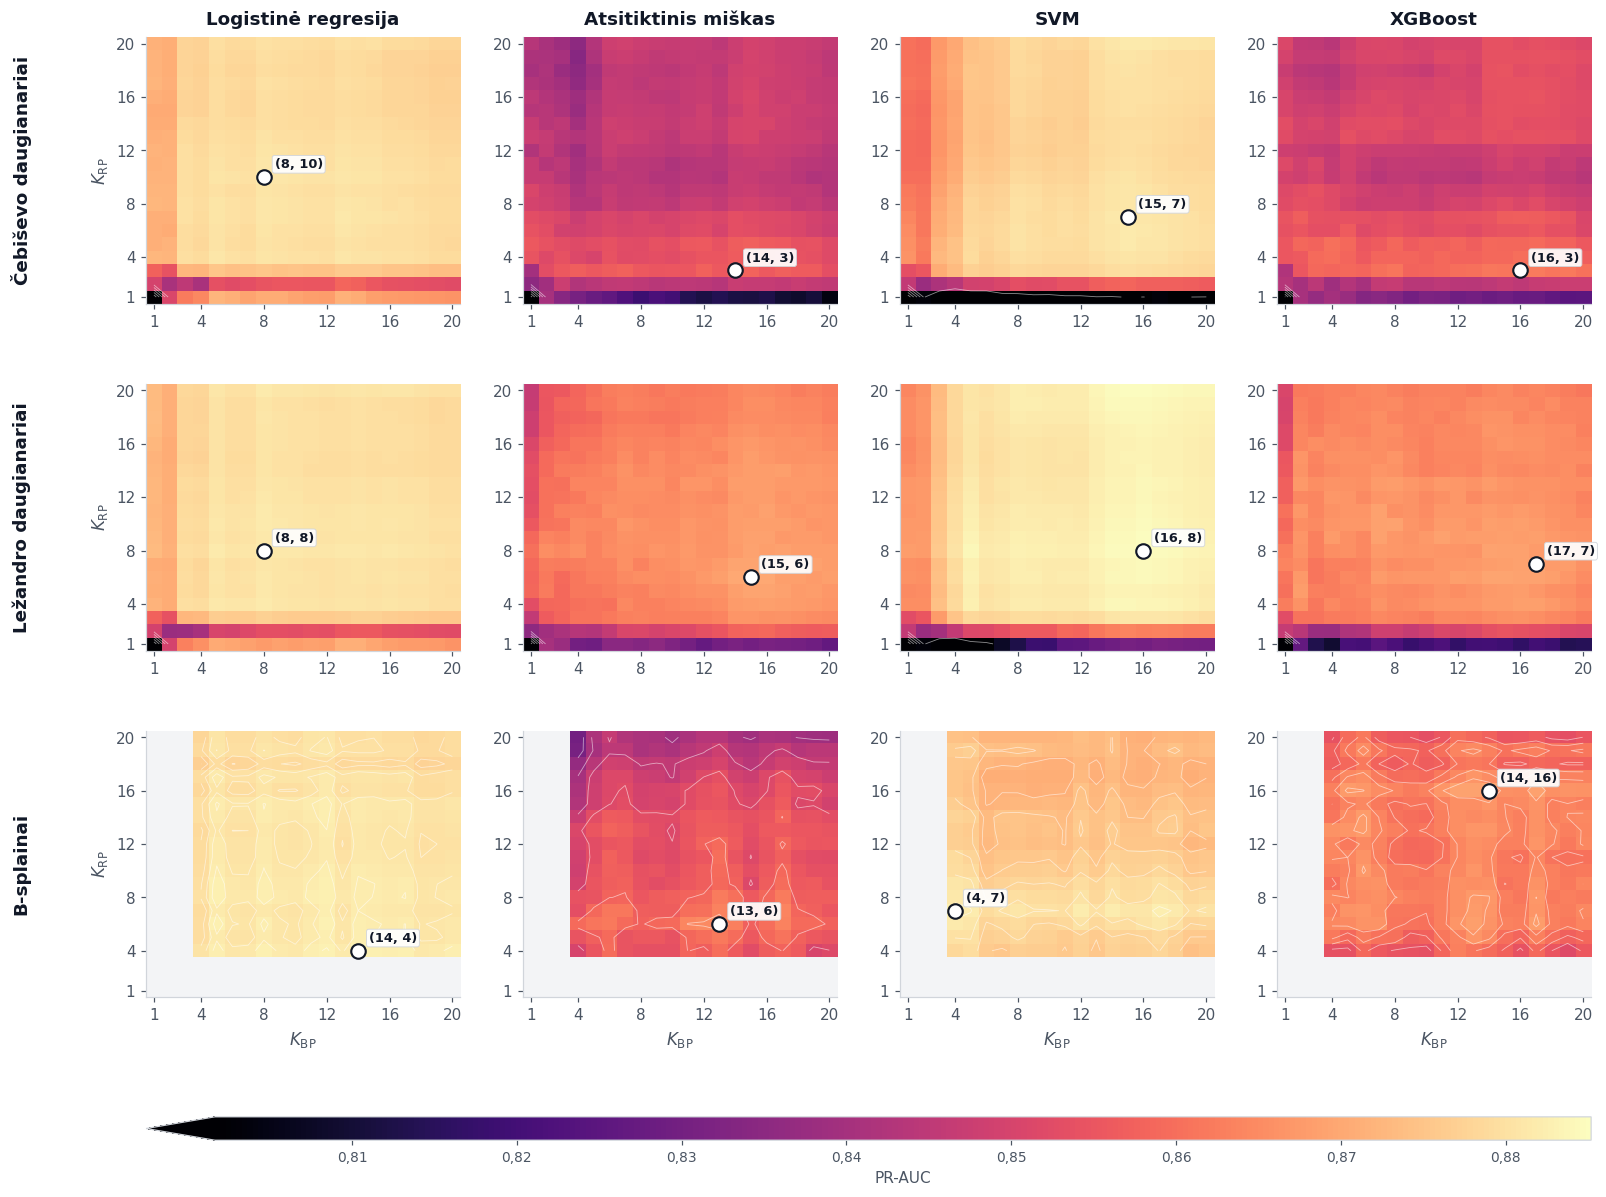

In [7]:
from matplotlib.colors import LinearSegmentedColormap

# Pastel kremos → levandos → tamsiai violetinė. Šviesumo gradientas monotoniškas,
# todėl paletė lieka draugiška daltonikams (protanopija/deuteranopija/tritanopija).
PASTEL_CMAP = LinearSegmentedColormap.from_list(
    "pastel_cream_to_purple",
    [
        (0.00, "#FFF6D6"),   # kremas
        (0.20, "#FCE3A8"),   # šviesus geltonas
        (0.42, "#F6B8C7"),   # rožinis
        (0.62, "#D1A6DD"),   # levanda
        (0.82, "#9C7BC4"),   # violetinė
        (1.00, "#5E4A93"),   # gilus violetinis
    ],
)


def _plot_pr_auc_surfaces(bases_to_show: list[str], fig_name: str) -> plt.Figure:
    classifiers_to_show = [c for c in CLASSIFIERS if c in df["classifier"].unique()]
    n_rows = len(bases_to_show)
    n_cols = len(classifiers_to_show)

    # Bendra spalvų skalė visam paveikslui:
    # vmin = mažiausias per-klasifikatoriaus 2-asis procentilis,
    # vmax = didžiausias per-klasifikatoriaus maksimumas.
    # Polinominių bazių K<4 ląstelės (kurios duoda ~0.3 PR-AUC) atsiduria
    # žemiau vmin ir matomos kaip „prisotintos“ kremo spalva (extend="min").
    per_clf_p02: list[float] = []
    per_clf_max: list[float] = []
    for clf in classifiers_to_show:
        vals_clf = []
        for basis in bases_to_show:
            Z, _, _ = surface(basis, clf)
            vals_clf.append(Z[~np.isnan(Z)])
        v = np.concatenate(vals_clf)
        per_clf_p02.append(float(np.quantile(v, 0.02)))
        per_clf_max.append(float(np.max(v)))
    global_vmin = float(min(per_clf_p02))
    global_vmax = float(max(per_clf_max))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.55 * n_cols + 0.9, 3.4 * n_rows + 1.6),
        squeeze=False,
    )

    cmap = plt.get_cmap("magma").copy()
    cmap.set_bad(color=ps.GRID_GRAY)

    for r, basis in enumerate(bases_to_show):
        for c, clf in enumerate(classifiers_to_show):
            ax = axes[r, c]
            Z, xs, ys = surface(basis, clf)
            Zm = np.ma.masked_invalid(Z)
            extent = [min(xs) - 0.5, max(xs) + 0.5, min(ys) - 0.5, max(ys) + 0.5]
            ax.imshow(
                Zm, origin="lower", extent=extent, cmap=cmap,
                vmin=global_vmin, vmax=global_vmax,
                aspect="auto", interpolation="nearest",
            )

            xg, yg = np.meshgrid(xs, ys)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                ax.contour(
                    xg, yg, Zm,
                    levels=6, colors="white",
                    linewidths=0.55, alpha=0.55,
                )

            k_bp, k_rp, _ = BEST_CELL.loc[(basis, clf)]
            ax.scatter([k_bp], [k_rp], s=90, marker="o",
                       facecolor="white", edgecolor=ps.TEXT_DARK,
                       linewidths=1.4, zorder=5)
            ax.annotate(
                f"({int(k_bp)}, {int(k_rp)})",
                xy=(k_bp, k_rp),
                xytext=(7, 6), textcoords="offset points",
                fontsize=8.5, fontweight="bold", color=ps.TEXT_DARK,
                bbox=dict(boxstyle="round,pad=0.18", fc="white",
                          ec=ps.AXIS_GRAY, lw=0.6, alpha=0.92),
                zorder=6,
            )

            xticks = sorted({min(xs), max(xs), *[t for t in xs if t % 4 == 0]})
            yticks = sorted({min(ys), max(ys), *[t for t in ys if t % 4 == 0]})
            ax.set_xticks(xticks)
            ax.set_yticks(yticks)
            for spine in ax.spines.values():
                spine.set_color(ps.AXIS_GRAY)
                spine.set_linewidth(0.8)
            ax.tick_params(axis="both", labelsize=10, colors=ps.TEXT_MUTED)

            if c == 0:
                ax.set_ylabel(K_RP_LABEL, fontsize=11, color=ps.TEXT_MUTED)
            if r == 0:
                ax.set_title(CLASSIFIERS_LT[clf], fontsize=12,
                             color=ps.TEXT_DARK, pad=8)
            if r == n_rows - 1:
                ax.set_xlabel(K_BP_LABEL, fontsize=11, color=ps.TEXT_MUTED)

    fig.subplots_adjust(left=0.10, right=0.97, top=0.92, bottom=0.18,
                        hspace=0.30, wspace=0.20)

    # Viena bendra spalvų skalė visam paveikslui, ištempta per visus stulpelius.
    left_pos = axes[-1, 0].get_position()
    right_pos = axes[-1, -1].get_position()
    cbar_x = left_pos.x0
    cbar_w = right_pos.x1 - left_pos.x0
    cbar_ax = fig.add_axes([cbar_x, left_pos.y0 - 0.11, cbar_w, 0.018])
    norm = Normalize(vmin=global_vmin, vmax=global_vmax)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", extend="min")
    cbar.set_label(
        f"{PR_AUC_LABEL}",
        fontsize=10, color=ps.TEXT_MUTED,
    )
    cbar.ax.tick_params(labelsize=9, colors=ps.TEXT_MUTED)
    cbar.ax.xaxis.set_major_formatter(ps.lt_comma_formatter(decimals=2))
    cbar.outline.set_edgecolor(ps.AXIS_GRAY)

    for r, basis in enumerate(bases_to_show):
        pos = axes[r, 0].get_position()
        fig.text(
            0.025, (pos.y0 + pos.y1) / 2,
            BASES_LT[basis],
            ha="center", va="center", rotation=90,
            fontsize=12, fontweight="bold", color=ps.TEXT_DARK,
        )

    save_figure(fig, fig_name)
    return fig


if RENDER_MAIN_8PANEL:
    fig13_main = _plot_pr_auc_surfaces(["chebyshev", "bspline"], "figure13_main")
    plt.show()
    fig13_app = _plot_pr_auc_surfaces(["chebyshev", "legendre", "bspline"], "figure13_appendix")
    plt.show()
else:
    fig13_main = _plot_pr_auc_surfaces(["chebyshev", "legendre", "bspline"], "figure13_main")
    plt.show()


## 1.1 Mažiausias $K$, kuriam paviršiaus PR-AUC dar nesiskiria nuo optimumo

Optimumai (balti apskritimai 13 paveiksle) yra ten, kur **vidutin\u0117 PR-AUC arg\u00a0max**. Vis d\u0117lto plat\u016bs PR-AUC „lygumai" rodo, kad gerokai ma\u017eesnis koeficient\u0173 skai\u010dius dauguma atvej\u0173 duoda **statisti\u0161kai neatskiriam\u0105** rezultat\u0105.

\u0160is diagnostinis blokas kiekvienai $(\text{baz\u0117}, \text{klasifikatorius})$ porai ie\u0161ko **ma\u017eiausio** $K_{BP} + K_{RP}$, kuriam 50 RSKF skilim\u0173 PR-AUC vektoriaus **porinis Vilkoksono \u017eenkluot\u0173j\u0173 rang\u0173 testas** prie\u0161 optimali\u0105 l\u0105stel\u0119 duoda $p > 0{,}05$ \u2014 t. y. nepavyksta atmesti hipotez\u0117s, kad l\u0105stel\u0117s yra ekvivalen\u010dios.

- Tikrinami tik kandidatai su $n_{koef} = K_{BP} + K_{RP} \leq n_{koef}^{opt}$.
- B-splainams papildomai $K_{BP}, K_{RP} \geq 4$ (žemiau l\u0105steli\u0173 n\u0117ra).
- Lygiosios per\u0161okamos \u0161ia prioritetine tvarka: 1) ma\u017eiausias $\max(K_{BP}, K_{RP})$, 2) labiausiai subalansuota pora ($|K_{BP} - K_{RP}|$ artimas 0).

Tikriausia hipotez\u0117: ma\u017eiausias K bus apie $(4,4)$ \u2014 pakankamai, kad i\u0161eit\u0173 i\u0161 polinomini\u0173 bazi\u0173 „katastrofos zonos" ($K \leq 3$), bet daugeliu atvej\u0173 nereik\u0117s eiti gerokai auk\u0161\u010diau.

In [8]:
from scipy.stats import wilcoxon

MIN_K_ALPHA = 0.05  # dvipusis porinis Vilkoksono testas


def _safe_wilcoxon_p(a: np.ndarray, b: np.ndarray) -> float:
    """Return Wilcoxon p; 1.0 when all paired differences are zero (e.g. opt vs opt)."""
    diffs = a - b
    if diffs.size == 0 or np.all(diffs == 0):
        return 1.0
    try:
        _, p = wilcoxon(diffs)
        return float(p)
    except ValueError:
        return 1.0


def _find_min_k_cell(basis: str, clf: str) -> dict:
    k_bp_opt_raw, k_rp_opt_raw, pr_opt = BEST_CELL.loc[(basis, clf)]
    k_bp_opt, k_rp_opt = int(k_bp_opt_raw), int(k_rp_opt_raw)
    n_coef_opt = k_bp_opt + k_rp_opt

    opt_vec = (
        df[(df["basis"] == basis) & (df["classifier"] == clf) &
           (df["K_BP"] == k_bp_opt) & (df["K_RP"] == k_rp_opt)]
        .sort_values("split")["pr_auc"].to_numpy()
    )

    cell_means = (
        df[(df["basis"] == basis) & (df["classifier"] == clf)]
        .groupby(["K_BP", "K_RP"])["pr_auc"].mean()
        .reset_index()
    )
    cell_means = cell_means[cell_means["K_BP"] + cell_means["K_RP"] <= n_coef_opt]
    if basis == "bspline":
        cell_means = cell_means[(cell_means["K_BP"] >= 4) & (cell_means["K_RP"] >= 4)]

    records: list[dict] = []
    for _, row in cell_means.iterrows():
        k_bp_c, k_rp_c = int(row["K_BP"]), int(row["K_RP"])
        cand_vec = (
            df[(df["basis"] == basis) & (df["classifier"] == clf) &
               (df["K_BP"] == k_bp_c) & (df["K_RP"] == k_rp_c)]
            .sort_values("split")["pr_auc"].to_numpy()
        )
        if cand_vec.size != opt_vec.size:
            continue
        p = _safe_wilcoxon_p(cand_vec, opt_vec)
        records.append({
            "K_BP":         k_bp_c,
            "K_RP":         k_rp_c,
            "n_coef":       k_bp_c + k_rp_c,
            "pr_auc_mean":  float(row["pr_auc"]),
            "p_wilcoxon":   p,
        })
    candidates = pd.DataFrame(records)

    indist = candidates[candidates["p_wilcoxon"] > MIN_K_ALPHA].copy()
    if indist.empty:
        indist = candidates[(candidates["K_BP"] == k_bp_opt) &
                            (candidates["K_RP"] == k_rp_opt)].copy()

    indist["max_k"] = indist[["K_BP", "K_RP"]].max(axis=1)
    indist["asymm"] = (indist["K_BP"] - indist["K_RP"]).abs()
    indist = indist.sort_values(
        ["n_coef", "max_k", "asymm", "K_BP"]
    ).reset_index(drop=True)
    winner = indist.iloc[0]

    return {
        "basis":          basis,
        "classifier":     clf,
        "K_BP_min":       int(winner["K_BP"]),
        "K_RP_min":       int(winner["K_RP"]),
        "n_coef_min":     int(winner["n_coef"]),
        "pr_auc_min":     float(winner["pr_auc_mean"]),
        "p_wilcoxon":     float(winner["p_wilcoxon"]),
        "K_BP_opt":       k_bp_opt,
        "K_RP_opt":       k_rp_opt,
        "n_coef_opt":     n_coef_opt,
        "pr_auc_opt":     float(pr_opt),
        "delta_pr_auc":   float(winner["pr_auc_mean"]) - float(pr_opt),
        "n_indist_cells": int(len(indist)),
    }


min_k_records: list[dict] = []
for basis in BASES:
    for clf in CLASSIFIERS:
        if (basis, clf) not in BEST_CELL.index:
            continue
        min_k_records.append(_find_min_k_cell(basis, clf))

min_k_raw = pd.DataFrame(min_k_records).reset_index(drop=True)

min_k_disp = pd.DataFrame({
    "Baz\u0117":                    min_k_raw["basis"].map(BASES_LT),
    "Klasifikatorius":           min_k_raw["classifier"].map(CLASSIFIERS_LT),
    r"$K_{BP}^{min}$":           min_k_raw["K_BP_min"],
    r"$K_{RP}^{min}$":           min_k_raw["K_RP_min"],
    r"$n_{koef}^{min}$":         min_k_raw["n_coef_min"],
    "PR-AUC (min)":              [lt_format(v, 4) for v in min_k_raw["pr_auc_min"]],
    "\u0394PR-AUC":              [lt_format(v, 4) for v in min_k_raw["delta_pr_auc"]],
    "p (Wilcoxon)":              [lt_format(v, 3) for v in min_k_raw["p_wilcoxon"]],
    r"$K_{BP}^{opt}$":           min_k_raw["K_BP_opt"],
    r"$K_{RP}^{opt}$":           min_k_raw["K_RP_opt"],
    r"$n_{koef}^{opt}$":         min_k_raw["n_coef_opt"],
    "PR-AUC (opt)":              [lt_format(v, 4) for v in min_k_raw["pr_auc_opt"]],
    "Ekvivalen\u010di\u0173 l\u0105steli\u0173": min_k_raw["n_indist_cells"],
}).reset_index(drop=True)


def _highlight_savings(row, raw=min_k_raw):
    n_min = int(raw.loc[row.name, "n_coef_min"])
    n_opt = int(raw.loc[row.name, "n_coef_opt"])
    if n_min <= n_opt / 2:
        return ["background-color: #e8f5d7" for _ in row]
    return ["" for _ in row]


styled_min_k = (
    min_k_disp.style
    .apply(_highlight_savings, axis=1)
    .set_caption(
        "1.1 lentel\u0117. Ma\u017eiausias $(K_{BP}, K_{RP})$, kurio 50-skilim\u0173 "
        "PR-AUC porinis Vilkoksono testas prie\u0161 optimum\u0105 duoda "
        "$p > 0{,}05$. \u017dalia \u0161viesa pa\u017eym\u0117tos eilut\u0117s, "
        "kuriose ma\u017eesn\u0117 konfig\u016bracija pasiekiama bent dvigubai "
        "ma\u017eesniu koeficient\u0173 skai\u010diumi nei optimumas."
    )
    .hide(axis="index")
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#f3f4f6"),
            ("color", ps.TEXT_MUTED),
            ("font-weight", "600"),
            ("text-align", "center"),
            ("border-bottom", f"1px solid {ps.AXIS_GRAY}"),
        ]},
        {"selector": "td", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [
            ("caption-side", "top"),
            ("font-style", "italic"),
            ("color", ps.TEXT_MUTED),
            ("padding-bottom", "6px"),
        ]},
    ])
)

print("Optimumas vs minimalus K (visi neatskiriami su p > 0.05, porinis Wilcoxon):")
print("-" * 92)
for _, r in min_k_raw.iterrows():
    print(
        f"  {r['basis']:10s} {r['classifier']:4s}: "
        f"opt=({r['K_BP_opt']:>2d},{r['K_RP_opt']:>2d}) n_opt={r['n_coef_opt']:>2d}  "
        f"min=({r['K_BP_min']:>2d},{r['K_RP_min']:>2d}) n_min={r['n_coef_min']:>2d}  "
        f"\u0394n={r['n_coef_opt'] - r['n_coef_min']:>3d}  "
        f"\u0394PR-AUC={r['delta_pr_auc']:+.4f}  "
        f"p={r['p_wilcoxon']:.3g}  "
        f"ekvival.={r['n_indist_cells']}"
    )
print("-" * 92)
print(
    f"Ma\u017eiausias n_koef per visus 12 deriniu: {int(min_k_raw['n_coef_min'].min())}, "
    f"didžiausias: {int(min_k_raw['n_coef_min'].max())}. "
    f"Vidutinis koeficient\u0173 sutaup. faktorius: "
    f"{(min_k_raw['n_coef_opt'] / min_k_raw['n_coef_min']).mean():.2f}\u00d7."
)

styled_min_k

Optimumas vs minimalus K (visi neatskiriami su p > 0.05, porinis Wilcoxon):
--------------------------------------------------------------------------------------------
  chebyshev  LR  : opt=( 8,10) n_opt=18  min=( 3, 4) n_min= 7  Δn= 11  ΔPR-AUC=-0.0015  p=0.0678  ekvival.=31
  chebyshev  RF  : opt=(14, 3) n_opt=17  min=( 1, 4) n_min= 5  Δn= 12  ΔPR-AUC=-0.0036  p=0.107  ekvival.=21
  chebyshev  SVM : opt=(15, 7) n_opt=22  min=( 8, 5) n_min=13  Δn=  9  ΔPR-AUC=-0.0014  p=0.0805  ekvival.=9
  chebyshev  XGB : opt=(16, 3) n_opt=19  min=( 3, 4) n_min= 7  Δn= 12  ΔPR-AUC=-0.0031  p=0.084  ekvival.=12
  legendre   LR  : opt=( 8, 8) n_opt=16  min=( 5, 4) n_min= 9  Δn=  7  ΔPR-AUC=-0.0007  p=0.118  ekvival.=4
  legendre   RF  : opt=(15, 6) n_opt=21  min=(12, 6) n_min=18  Δn=  3  ΔPR-AUC=-0.0029  p=0.0708  ekvival.=7
  legendre   SVM : opt=(16, 8) n_opt=24  min=( 5, 8) n_min=13  Δn= 11  ΔPR-AUC=-0.0011  p=0.0635  ekvival.=2
  legendre   XGB : opt=(17, 7) n_opt=24  min=( 2, 4) n_min= 6  Δn= 1

Bazė,Klasifikatorius,$K_{BP}^{min}$,$K_{RP}^{min}$,$n_{koef}^{min}$,PR-AUC (min),ΔPR-AUC,p (Wilcoxon),$K_{BP}^{opt}$,$K_{RP}^{opt}$,$n_{koef}^{opt}$,PR-AUC (opt),Ekvivalenčių ląstelių
Čebiševo daugianariai,Logistinė regresija,3,4,7,"0,8798","-0,0015","0,068",8,10,18,"0,8813",31
Čebiševo daugianariai,Atsitiktinis miškas,1,4,5,"0,8547","-0,0036","0,107",14,3,17,"0,8583",21
Čebiševo daugianariai,SVM,8,5,13,"0,8804","-0,0014","0,081",15,7,22,"0,8818",9
Čebiševo daugianariai,XGBoost,3,4,7,"0,8592","-0,0031","0,084",16,3,19,"0,8622",12
Ležandro daugianariai,Logistinė regresija,5,4,9,"0,8814","-0,0007","0,118",8,8,16,"0,8821",4
Ležandro daugianariai,Atsitiktinis miškas,12,6,18,"0,8673","-0,0029","0,071",15,6,21,"0,8702",7
Ležandro daugianariai,SVM,5,8,13,"0,8840","-0,0011","0,063",16,8,24,"0,8852",2
Ležandro daugianariai,XGBoost,2,4,6,"0,8663","-0,0034","0,082",17,7,24,"0,8697",46
B-splainai,Logistinė regresija,5,4,9,"0,8825","-0,0009","0,101",14,4,18,"0,8834",15
B-splainai,Atsitiktinis miškas,6,6,12,"0,8620","-0,0037","0,084",13,6,19,"0,8657",4


## 2. 6 lentelė — geriausi (basis × classifier) deriniai

12 eilučių (3 bazės × 4 klasifikatoriai). Operacijos taško metrikos (jautrumas, specifiškumas, tikslumas, F1) imamos **prie F1-optimuoto slenksčio** — atitinka `F1-optimuotas` slenksčio politiką, kuri yra eksplicitiškai įrašyta į atskirą stulpelį. PR-AUC ir ROC-AUC nepriklauso nuo slenksčio.

Visi dydžiai pateikiami kaip vidurkis $\pm$ standartinis nuokrypis per 50 splitų, suapvalinta iki 3 skaitmenų po kablelio. Globaliai geriausia eilutė (pagal `pr_auc_mean`) paryškinta — ji atitinka pirminę darbo „best of best“ rekomendaciją.


In [9]:
def _best_cell_metrics(basis: str, clf: str) -> dict:
    k_bp, k_rp, _ = BEST_CELL.loc[(basis, clf)]
    cell = df[(df["basis"] == basis) & (df["classifier"] == clf) &
              (df["K_BP"] == int(k_bp)) & (df["K_RP"] == int(k_rp))]
    cols = {
        "pr_auc":      "pr_auc",
        "roc_auc":     "roc_auc",
        "f1":          "f1_f1",
        "sensitivity": "sensitivity_f1",
        "specificity": "specificity_f1",
        "precision":   "precision_f1",
    }
    row = {
        "_basis":          basis,
        "_clf":            clf,
        "basis":           BASES_LT[basis],
        "classifier":      CLASSIFIERS_LT[clf],
        "K_BP":            int(k_bp),
        "K_RP":            int(k_rp),
        "n_coef":          int(k_bp + k_rp),
    }
    for short, col in cols.items():
        row[f"{short}_mean"] = cell[col].mean()
        row[f"{short}_std"]  = cell[col].std()
    row["threshold_policy"] = "F1-optimuotas"
    return row


rows_t6 = []
for basis in BASES:
    for clf in [c for c in CLASSIFIERS if c in df["classifier"].unique()]:
        rows_t6.append(_best_cell_metrics(basis, clf))

table6_raw = pd.DataFrame(rows_t6)
global_best_idx = int(table6_raw["pr_auc_mean"].idxmax())


def _fmt_pm(r, short):
    return lt_format_pm(r[f"{short}_mean"], r[f"{short}_std"])


t6_display = pd.DataFrame({
    "Bazė":                   table6_raw["basis"],
    "Klasifikatorius":        table6_raw["classifier"],
    "K_BP":                   table6_raw["K_BP"],
    "K_RP":                   table6_raw["K_RP"],
    "n_coef":                 table6_raw["n_coef"],
    "PR-AUC":                 [_fmt_pm(r, "pr_auc") for _, r in table6_raw.iterrows()],
    "ROC-AUC":                [_fmt_pm(r, "roc_auc") for _, r in table6_raw.iterrows()],
    "F1":                     [_fmt_pm(r, "f1") for _, r in table6_raw.iterrows()],
    "Jautrumas":              [_fmt_pm(r, "sensitivity") for _, r in table6_raw.iterrows()],
    "Specifiškumas":          [_fmt_pm(r, "specificity") for _, r in table6_raw.iterrows()],
    "Tikslumas (precision)":  [_fmt_pm(r, "precision") for _, r in table6_raw.iterrows()],
    "Slenksčio politika":     table6_raw["threshold_policy"],
})


def _bold_best(row):
    return [
        "font-weight: bold; background-color: #fff7d6"
        if row.name == global_best_idx else ""
        for _ in row
    ]


styled_t6 = (
    t6_display.style
    .apply(_bold_best, axis=1)
    .set_caption(
        "6 lentelė. Optimal\u016bs $(K_{BP}, K_{RP})$ deriniai pagal vidutin\u0119 PR-AUC "
        "(50 RSKF split\u0173). Visos operacijos ta\u0161ko metrikos prie F1 slenks\u010dio."
    )
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#f3f4f6"),
            ("color", ps.TEXT_MUTED),
            ("font-weight", "600"),
            ("text-align", "center"),
            ("border-bottom", f"1px solid {ps.AXIS_GRAY}"),
        ]},
        {"selector": "td", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [
            ("caption-side", "top"),
            ("font-style", "italic"),
            ("color", ps.TEXT_MUTED),
            ("padding-bottom", "6px"),
        ]},
    ])
)
styled_t6


,Bazė,Klasifikatorius,K_BP,K_RP,n_coef,PR-AUC,ROC-AUC,F1,Jautrumas,Specifiškumas,Tikslumas (precision),Slenksčio politika
0,Čebiševo daugianariai,Logistinė regresija,8,10,18,"0,881 ± 0,024","0,928 ± 0,015","0,839 ± 0,026","0,794 ± 0,036","0,976 ± 0,007","0,891 ± 0,030",F1-optimuotas
1,Čebiševo daugianariai,Atsitiktinis miškas,14,3,17,"0,858 ± 0,026","0,918 ± 0,015","0,800 ± 0,032","0,771 ± 0,041","0,961 ± 0,013","0,834 ± 0,047",F1-optimuotas
2,Čebiševo daugianariai,SVM,15,7,22,"0,882 ± 0,024","0,927 ± 0,016","0,830 ± 0,026","0,783 ± 0,039","0,974 ± 0,009","0,884 ± 0,034",F1-optimuotas
3,Čebiševo daugianariai,XGBoost,16,3,19,"0,862 ± 0,025","0,919 ± 0,015","0,808 ± 0,030","0,758 ± 0,041","0,971 ± 0,011","0,868 ± 0,043",F1-optimuotas
4,Ležandro daugianariai,Logistinė regresija,8,8,16,"0,882 ± 0,024","0,929 ± 0,015","0,836 ± 0,025","0,792 ± 0,039","0,975 ± 0,009","0,887 ± 0,034",F1-optimuotas
5,Ležandro daugianariai,Atsitiktinis miškas,15,6,21,"0,870 ± 0,025","0,922 ± 0,016","0,810 ± 0,028","0,776 ± 0,045","0,966 ± 0,014","0,852 ± 0,047",F1-optimuotas
6,Ležandro daugianariai,SVM,16,8,24,"0,885 ± 0,023","0,929 ± 0,016","0,845 ± 0,024","0,797 ± 0,035","0,978 ± 0,007","0,899 ± 0,030",F1-optimuotas
7,Ležandro daugianariai,XGBoost,17,7,24,"0,870 ± 0,025","0,927 ± 0,015","0,809 ± 0,027","0,782 ± 0,040","0,963 ± 0,013","0,841 ± 0,044",F1-optimuotas
8,B-splainai,Logistinė regresija,14,4,18,"0,883 ± 0,024","0,930 ± 0,015","0,840 ± 0,025","0,799 ± 0,034","0,974 ± 0,010","0,888 ± 0,040",F1-optimuotas
9,B-splainai,Atsitiktinis miškas,13,6,19,"0,866 ± 0,024","0,921 ± 0,015","0,810 ± 0,027","0,767 ± 0,039","0,969 ± 0,009","0,859 ± 0,035",F1-optimuotas


## 2.1 6.1 lentelė — mažiausių pakankamų konfigūracijų metrikos

Tos pačios 12 eilučių (3 bazės × 4 klasifikatoriai), tačiau vietoj PR-AUC optimumų pateikiamos **mažiausios pakankamos** $(K_{BP}^{\min}, K_{RP}^{\min})$ konfigūracijos iš 1.1 lentelės — t. y. ląstelės, kurių 50-skilimų PR-AUC porinis Vilkoksono testas prieš atitinkamą $(basis, classifier)$ optimumą duoda $p > 0{,}05$. Operacijos taško metrikos (jautrumas, specifiškumas, tikslumas, F1) imamos **prie F1-optimuoto slenksčio**, lygiai kaip 6 lentelėje; PR-AUC ir ROC-AUC nepriklauso nuo slenksčio.

Visi dydžiai pateikiami kaip vidurkis $\pm$ standartinis nuokrypis per 50 RSKF splitų, suapvalinta iki 3 skaitmenų po kablelio. Paryškinta eilutė — kompaktiškiausia konfigūracija pagal $n_{koef}^{\min} = K_{BP}^{\min} + K_{RP}^{\min}$ (lygiosios sprendžiamos pagal didžiausią vidutinę PR-AUC).


In [10]:
def _min_cell_metrics(rec: pd.Series) -> dict:
    basis = rec["basis"]
    clf = rec["classifier"]
    k_bp = int(rec["K_BP_min"])
    k_rp = int(rec["K_RP_min"])
    cell = df[(df["basis"] == basis) & (df["classifier"] == clf) &
              (df["K_BP"] == k_bp) & (df["K_RP"] == k_rp)]
    cols = {
        "pr_auc":      "pr_auc",
        "roc_auc":     "roc_auc",
        "f1":          "f1_f1",
        "sensitivity": "sensitivity_f1",
        "specificity": "specificity_f1",
        "precision":   "precision_f1",
    }
    out = {
        "_basis":     basis,
        "_clf":       clf,
        "basis":      BASES_LT[basis],
        "classifier": CLASSIFIERS_LT[clf],
        "K_BP":       k_bp,
        "K_RP":       k_rp,
        "n_coef":     k_bp + k_rp,
        "p_wilcoxon": float(rec["p_wilcoxon"]),
        "delta_pr_auc": float(rec["delta_pr_auc"]),
    }
    for short, col in cols.items():
        out[f"{short}_mean"] = cell[col].mean()
        out[f"{short}_std"]  = cell[col].std()
    out["threshold_policy"] = "F1-optimuotas"
    return out


rows_t6_min = [_min_cell_metrics(r) for _, r in min_k_raw.iterrows()]
table6_min_raw = pd.DataFrame(rows_t6_min)

# Kompaktiškiausia eilutė: mažiausias n_coef; lygiosios → didžiausia PR-AUC.
most_compact_idx = int(
    table6_min_raw
    .sort_values(["n_coef", "pr_auc_mean"], ascending=[True, False])
    .index[0]
)


t6_min_display = pd.DataFrame({
    "Bazė":                   table6_min_raw["basis"],
    "Klasifikatorius":        table6_min_raw["classifier"],
    "K_BP":                   table6_min_raw["K_BP"],
    "K_RP":                   table6_min_raw["K_RP"],
    "n_coef":                 table6_min_raw["n_coef"],
    "PR-AUC":                 [_fmt_pm(r, "pr_auc") for _, r in table6_min_raw.iterrows()],
    "ROC-AUC":                [_fmt_pm(r, "roc_auc") for _, r in table6_min_raw.iterrows()],
    "F1":                     [_fmt_pm(r, "f1") for _, r in table6_min_raw.iterrows()],
    "Jautrumas":              [_fmt_pm(r, "sensitivity") for _, r in table6_min_raw.iterrows()],
    "Specifiškumas":          [_fmt_pm(r, "specificity") for _, r in table6_min_raw.iterrows()],
    "Tikslumas (precision)":  [_fmt_pm(r, "precision") for _, r in table6_min_raw.iterrows()],
    "Slenksčio politika":     table6_min_raw["threshold_policy"],
})


def _bold_compact(row):
    return [
        "font-weight: bold; background-color: #fff7d6"
        if row.name == most_compact_idx else ""
        for _ in row
    ]


styled_t6_min = (
    t6_min_display.style
    .apply(_bold_compact, axis=1)
    .set_caption(
        "6.1 lentelė. Mažiausių pakankamų $(K_{BP}^{\\min}, K_{RP}^{\\min})$ konfigūracijų "
        "operacijos taško metrikos (F1-optimuotas slenkstis, 50 RSKF splitų). "
        "Paryškinta eilutė — kompaktiškiausia konfigūracija pagal $n_{koef}^{\\min}$ "
        "(lygiosios sprendžiamos pagal didžiausią PR-AUC)."
    )
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#f3f4f6"),
            ("color", ps.TEXT_MUTED),
            ("font-weight", "600"),
            ("text-align", "center"),
            ("border-bottom", f"1px solid {ps.AXIS_GRAY}"),
        ]},
        {"selector": "td", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [
            ("caption-side", "top"),
            ("font-style", "italic"),
            ("color", ps.TEXT_MUTED),
            ("padding-bottom", "6px"),
        ]},
    ])
)

print("Mažiausių pakankamų konfigūracijų metrikos (F1-optimuotas slenkstis):")
print("-" * 92)
for _, r in table6_min_raw.iterrows():
    print(
        f"  {r['_basis']:10s} {r['_clf']:4s}: "
        f"(K_BP={r['K_BP']:>2d}, K_RP={r['K_RP']:>2d}) n={r['n_coef']:>2d}  "
        f"PR-AUC={r['pr_auc_mean']:.4f}±{r['pr_auc_std']:.4f}  "
        f"ROC-AUC={r['roc_auc_mean']:.4f}±{r['roc_auc_std']:.4f}  "
        f"F1={r['f1_mean']:.4f}±{r['f1_std']:.4f}"
    )
print("-" * 92)
print(
    f"Kompaktiškiausia eilutė: "
    f"{table6_min_raw.loc[most_compact_idx, '_basis']} / "
    f"{table6_min_raw.loc[most_compact_idx, '_clf']} "
    f"(n_coef={int(table6_min_raw.loc[most_compact_idx, 'n_coef'])}, "
    f"PR-AUC={table6_min_raw.loc[most_compact_idx, 'pr_auc_mean']:.4f})."
)

styled_t6_min


Mažiausių pakankamų konfigūracijų metrikos (F1-optimuotas slenkstis):
--------------------------------------------------------------------------------------------
  chebyshev  LR  : (K_BP= 3, K_RP= 4) n= 7  PR-AUC=0.8798±0.0268  ROC-AUC=0.9311±0.0147  F1=0.8340±0.0263
  chebyshev  RF  : (K_BP= 1, K_RP= 4) n= 5  PR-AUC=0.8547±0.0318  ROC-AUC=0.9210±0.0169  F1=0.8064±0.0298
  chebyshev  SVM : (K_BP= 8, K_RP= 5) n=13  PR-AUC=0.8804±0.0249  ROC-AUC=0.9258±0.0166  F1=0.8314±0.0286
  chebyshev  XGB : (K_BP= 3, K_RP= 4) n= 7  PR-AUC=0.8592±0.0283  ROC-AUC=0.9129±0.0187  F1=0.8134±0.0306
  legendre   LR  : (K_BP= 5, K_RP= 4) n= 9  PR-AUC=0.8814±0.0251  ROC-AUC=0.9297±0.0151  F1=0.8358±0.0266
  legendre   RF  : (K_BP=12, K_RP= 6) n=18  PR-AUC=0.8673±0.0268  ROC-AUC=0.9207±0.0165  F1=0.8122±0.0276
  legendre   SVM : (K_BP= 5, K_RP= 8) n=13  PR-AUC=0.8840±0.0239  ROC-AUC=0.9294±0.0158  F1=0.8333±0.0263
  legendre   XGB : (K_BP= 2, K_RP= 4) n= 6  PR-AUC=0.8663±0.0283  ROC-AUC=0.9243±0.0156  F1=0.8

,Bazė,Klasifikatorius,K_BP,K_RP,n_coef,PR-AUC,ROC-AUC,F1,Jautrumas,Specifiškumas,Tikslumas (precision),Slenksčio politika
0,Čebiševo daugianariai,Logistinė regresija,3,4,7,"0,880 ± 0,027","0,931 ± 0,015","0,834 ± 0,026","0,796 ± 0,037","0,972 ± 0,010","0,877 ± 0,037",F1-optimuotas
1,Čebiševo daugianariai,Atsitiktinis miškas,1,4,5,"0,855 ± 0,032","0,921 ± 0,017","0,806 ± 0,030","0,766 ± 0,035","0,967 ± 0,013","0,853 ± 0,047",F1-optimuotas
2,Čebiševo daugianariai,SVM,8,5,13,"0,880 ± 0,025","0,926 ± 0,017","0,831 ± 0,029","0,792 ± 0,039","0,972 ± 0,010","0,877 ± 0,038",F1-optimuotas
3,Čebiševo daugianariai,XGBoost,3,4,7,"0,859 ± 0,028","0,913 ± 0,019","0,813 ± 0,031","0,765 ± 0,040","0,971 ± 0,010","0,870 ± 0,039",F1-optimuotas
4,Ležandro daugianariai,Logistinė regresija,5,4,9,"0,881 ± 0,025","0,930 ± 0,015","0,836 ± 0,027","0,801 ± 0,037","0,971 ± 0,011","0,875 ± 0,040",F1-optimuotas
5,Ležandro daugianariai,Atsitiktinis miškas,12,6,18,"0,867 ± 0,027","0,921 ± 0,017","0,812 ± 0,028","0,776 ± 0,040","0,967 ± 0,012","0,854 ± 0,045",F1-optimuotas
6,Ležandro daugianariai,SVM,5,8,13,"0,884 ± 0,024","0,929 ± 0,016","0,833 ± 0,026","0,783 ± 0,039","0,976 ± 0,009","0,892 ± 0,034",F1-optimuotas
7,Ležandro daugianariai,XGBoost,2,4,6,"0,866 ± 0,028","0,924 ± 0,016","0,812 ± 0,025","0,771 ± 0,035","0,969 ± 0,012","0,861 ± 0,042",F1-optimuotas
8,B-splainai,Logistinė regresija,5,4,9,"0,883 ± 0,024","0,929 ± 0,015","0,840 ± 0,027","0,800 ± 0,037","0,974 ± 0,009","0,885 ± 0,034",F1-optimuotas
9,B-splainai,Atsitiktinis miškas,6,6,12,"0,862 ± 0,026","0,922 ± 0,016","0,808 ± 0,025","0,764 ± 0,038","0,968 ± 0,011","0,859 ± 0,040",F1-optimuotas


## 3. 14 paveikslas — PR-AUC dėžučių grafikai

Trys facetai (po vieną bazei). Kiekviename facete – keturios dėžutės (po vieną klasifikatoriui) su 50 splitų PR-AUC reikšmėmis **prie kiekvienos $(basis, classifier)$ poros optimalios ląstelės**. Bendra y ašis. Virš dėžučių jaunesniu lygmeniu uždedami 50 individualių taškų su mažu jitteriu (`alpha = 0.35`), kad būtų matomas duomenų pasiskirstymas, o ne tik kvartilinė statistika.


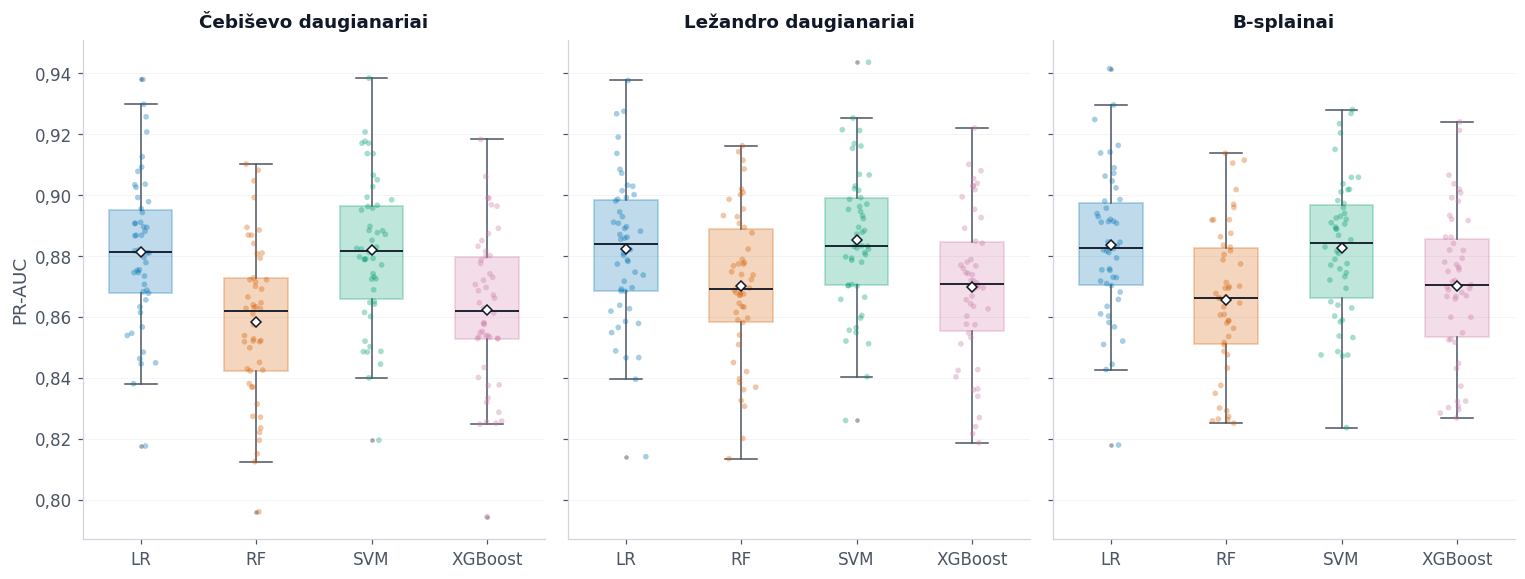

In [11]:
classifiers_to_show = [c for c in CLASSIFIERS if c in df["classifier"].unique()]

fig14, axes14 = plt.subplots(
    1, len(BASES), figsize=(14.0, 5.4), sharey=True,
)
if len(BASES) == 1:
    axes14 = [axes14]

rng = np.random.default_rng(42)
for ax, basis in zip(axes14, BASES):
    box_data: list[np.ndarray] = []
    box_positions: list[int] = []
    box_colors: list[str] = []
    used_clfs: list[str] = []

    for i, clf in enumerate(classifiers_to_show):
        try:
            k_bp, k_rp, _ = BEST_CELL.loc[(basis, clf)]
        except KeyError:
            continue
        vals = df[(df["basis"] == basis) & (df["classifier"] == clf) &
                  (df["K_BP"] == int(k_bp)) & (df["K_RP"] == int(k_rp))]["pr_auc"].to_numpy()
        box_data.append(vals)
        box_positions.append(i)
        box_colors.append(CLASSIFIER_COLORS[clf])
        used_clfs.append(clf)

    bp = ax.boxplot(
        box_data, positions=box_positions, widths=0.55, patch_artist=True,
        showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="white",
                       markeredgecolor=ps.TEXT_DARK, markersize=5),
        medianprops=dict(color=ps.TEXT_DARK, linewidth=1.2),
        flierprops=dict(marker="o", markersize=3, alpha=0.5,
                        markerfacecolor=ps.TEXT_MUTED, markeredgecolor="none"),
        whiskerprops=dict(color=ps.TEXT_MUTED, linewidth=1.0),
        capprops=dict(color=ps.TEXT_MUTED, linewidth=1.0),
    )
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.25)
        patch.set_edgecolor(color)
        patch.set_linewidth(1.3)

    for pos, vals, color in zip(box_positions, box_data, box_colors):
        jitter = rng.normal(loc=pos, scale=0.06, size=len(vals))
        ax.scatter(jitter, vals, color=color, alpha=0.35, s=14,
                   edgecolor="none", zorder=2)

    ax.set_xticks(box_positions)
    ax.set_xticklabels([CLASSIFIERS_TICK[c] for c in used_clfs],
                       rotation=0, ha="center")
    ax.set_title(BASES_LT[basis], fontsize=12, color=ps.TEXT_DARK, pad=8)
    ps.apply_style(ax, grid_axis="y")

axes14[0].set_ylabel(PR_AUC_LABEL, fontsize=12, color=ps.TEXT_MUTED)
for ax in axes14:
    ax.yaxis.set_major_formatter(ps.lt_comma_formatter(decimals=2))
fig14.tight_layout()
save_figure(fig14, "figure14")
plt.show()


## 4. 7 lentelė — porinis Wilcoxon ženkluotųjų rangų testas

Visi testai atliekami **porinai** per 50 splitų PR-AUC reikšmes ties kiekvienos $(basis, classifier)$ poros optimalia ląstele. Suskirstyta į tris šeimas; **kiekviena pošeimė turi savo Bonferroni $m$**, kad reikšmingumo skirtumai būtų aiškūs:

1. **Bazė vs bazė**
   - **1a** — atskirai kiekvienam klasifikatoriui (3 poros × 4 clf = $m = 12$).
   - **1b** — apjungus visus klasifikatorius (3 poros, $m = 3$). Apjungimas: kiekvieno klasifikatoriaus     optimaliausių ląstelių 50-splitų PR-AUC vektoriai konkatenuojami.
2. **Klasifikatorius vs klasifikatorius**
   - **2a** — atskirai kiekvienai bazei (6 poros × 3 bazės = $m = 18$).
   - **2b** — apjungus visas bazes (6 poros, $m = 6$).
3. **Kompaktiškumas** — geriausia žemo-$K$ ląstelė ($K_{\mathrm{BP}}, K_{\mathrm{RP}} \leq 8$) vs $(K_{\mathrm{BP}} = 20, K_{\mathrm{RP}} = 20)$ ląstelė, kiekvienai (basis, classifier) porai ($m = 12$).

Stulpeliai: `comparison_type, group_a, group_b, statistic, p_value_raw, p_value_bonferroni, n_comparisons_m, significant_at_0.05`. Bonferroni $p$ apskaičiuojama kaip $\min(p_\text{raw} \cdot m, 1)$. Reikšmingumas pasiekiamas, kai šis koreguotas $p < 0{,}05$.


In [12]:
def _pr_auc_vector(basis: str, clf: str, k_bp: int, k_rp: int) -> pd.Series:
    cell = df[(df["basis"] == basis) & (df["classifier"] == clf) &
              (df["K_BP"] == k_bp) & (df["K_RP"] == k_rp)]
    return cell.set_index("split")["pr_auc"].sort_index()


def _wilcoxon_paired(a: pd.Series, b: pd.Series) -> tuple[float, float]:
    common = a.index.intersection(b.index)
    if len(common) < 5:
        return float("nan"), float("nan")
    a2 = a.loc[common].to_numpy()
    b2 = b.loc[common].to_numpy()
    if np.all(a2 == b2):
        return 0.0, 1.0
    try:
        stat, p = stats.wilcoxon(a2, b2, zero_method="wilcox", alternative="two-sided")
    except ValueError:
        return float("nan"), float("nan")
    return float(stat), float(p)


clf_pairs = list(combinations(CLASSIFIERS, 2))
basis_pairs = list(combinations(BASES, 2))
available_clfs = [c for c in CLASSIFIERS if c in df["classifier"].unique()]

results: list[dict] = []

# Family 1a — basis vs basis per classifier
m_1a = len(available_clfs) * len(basis_pairs)
for clf in available_clfs:
    for ba, bb in basis_pairs:
        ka_bp, ka_rp, _ = BEST_CELL.loc[(ba, clf)]
        kb_bp, kb_rp, _ = BEST_CELL.loc[(bb, clf)]
        va = _pr_auc_vector(ba, clf, int(ka_bp), int(ka_rp))
        vb = _pr_auc_vector(bb, clf, int(kb_bp), int(kb_rp))
        stat, p = _wilcoxon_paired(va, vb)
        p_adj = min(p * m_1a, 1.0) if not np.isnan(p) else float("nan")
        results.append({
            "comparison_type":    f"1a · bazė vs bazė ({CLASSIFIERS_LT[clf]})",
            "group_a":            BASES_LT[ba],
            "group_b":            BASES_LT[bb],
            "statistic":          stat,
            "p_value_raw":        p,
            "p_value_bonferroni": p_adj,
            "n_comparisons_m":    m_1a,
            "significant_at_0.05": bool(p_adj < 0.05) if not np.isnan(p_adj) else False,
        })


def _pooled_basis_vector(basis: str) -> pd.Series:
    parts = []
    for clf in available_clfs:
        k_bp, k_rp, _ = BEST_CELL.loc[(basis, clf)]
        v = _pr_auc_vector(basis, clf, int(k_bp), int(k_rp))
        v.index = [f"{clf}__{i}" for i in v.index]
        parts.append(v)
    return pd.concat(parts)


# Family 1b — basis vs basis pooled across classifiers
m_1b = len(basis_pairs)
for ba, bb in basis_pairs:
    va = _pooled_basis_vector(ba)
    vb = _pooled_basis_vector(bb)
    stat, p = _wilcoxon_paired(va, vb)
    p_adj = min(p * m_1b, 1.0) if not np.isnan(p) else float("nan")
    results.append({
        "comparison_type":    "1b · bazė vs bazė (sujungta per klasifikatorius)",
        "group_a":            BASES_LT[ba],
        "group_b":            BASES_LT[bb],
        "statistic":          stat,
        "p_value_raw":        p,
        "p_value_bonferroni": p_adj,
        "n_comparisons_m":    m_1b,
        "significant_at_0.05": bool(p_adj < 0.05) if not np.isnan(p_adj) else False,
    })

# Family 2a — classifier vs classifier per basis
m_2a = len(BASES) * len(clf_pairs) if len(available_clfs) >= 2 else 0
for basis in BASES:
    for ca, cb in clf_pairs:
        if ca not in available_clfs or cb not in available_clfs:
            continue
        ka_bp, ka_rp, _ = BEST_CELL.loc[(basis, ca)]
        kb_bp, kb_rp, _ = BEST_CELL.loc[(basis, cb)]
        va = _pr_auc_vector(basis, ca, int(ka_bp), int(ka_rp))
        vb = _pr_auc_vector(basis, cb, int(kb_bp), int(kb_rp))
        stat, p = _wilcoxon_paired(va, vb)
        p_adj = min(p * m_2a, 1.0) if (m_2a and not np.isnan(p)) else float("nan")
        results.append({
            "comparison_type":    f"2a · clf vs clf ({BASES_LT[basis]})",
            "group_a":            CLASSIFIERS_LT[ca],
            "group_b":            CLASSIFIERS_LT[cb],
            "statistic":          stat,
            "p_value_raw":        p,
            "p_value_bonferroni": p_adj,
            "n_comparisons_m":    m_2a,
            "significant_at_0.05": bool(p_adj < 0.05) if not np.isnan(p_adj) else False,
        })


def _pooled_clf_vector(clf: str) -> pd.Series:
    parts = []
    for basis in BASES:
        k_bp, k_rp, _ = BEST_CELL.loc[(basis, clf)]
        v = _pr_auc_vector(basis, clf, int(k_bp), int(k_rp))
        v.index = [f"{basis}__{i}" for i in v.index]
        parts.append(v)
    return pd.concat(parts)


# Family 2b — classifier vs classifier pooled across bases
m_2b = len(clf_pairs) if len(available_clfs) >= 2 else 0
for ca, cb in clf_pairs:
    if ca not in available_clfs or cb not in available_clfs:
        continue
    va = _pooled_clf_vector(ca)
    vb = _pooled_clf_vector(cb)
    stat, p = _wilcoxon_paired(va, vb)
    p_adj = min(p * m_2b, 1.0) if (m_2b and not np.isnan(p)) else float("nan")
    results.append({
        "comparison_type":    "2b · clf vs clf (sujungta per bazes)",
        "group_a":            CLASSIFIERS_LT[ca],
        "group_b":            CLASSIFIERS_LT[cb],
        "statistic":          stat,
        "p_value_raw":        p,
        "p_value_bonferroni": p_adj,
        "n_comparisons_m":    m_2b,
        "significant_at_0.05": bool(p_adj < 0.05) if not np.isnan(p_adj) else False,
    })

# Family 3 — compactness, per (basis, classifier)
m_3 = len(BASES) * len(available_clfs)
COMPACT_K_MAX = 8
for basis in BASES:
    for clf in available_clfs:
        sub = df[(df["basis"] == basis) & (df["classifier"] == clf) &
                 (df["K_BP"] <= COMPACT_K_MAX) & (df["K_RP"] <= COMPACT_K_MAX)]
        means = sub.groupby(["K_BP", "K_RP"])["pr_auc"].mean()
        if means.empty:
            continue
        k_bp_lo, k_rp_lo = means.idxmax()
        v_lo = _pr_auc_vector(basis, clf, int(k_bp_lo), int(k_rp_lo))
        v_hi = _pr_auc_vector(basis, clf, 20, 20)
        stat, p = _wilcoxon_paired(v_lo, v_hi)
        p_adj = min(p * m_3, 1.0) if not np.isnan(p) else float("nan")
        results.append({
            "comparison_type":    f"3 · kompakti\u0161kumas ({BASES_LT[basis]} / {CLASSIFIERS_LT[clf]})",
            "group_a":            f"(K_BP={int(k_bp_lo)}, K_RP={int(k_rp_lo)})",
            "group_b":            "(K_BP=20, K_RP=20)",
            "statistic":          stat,
            "p_value_raw":        p,
            "p_value_bonferroni": p_adj,
            "n_comparisons_m":    m_3,
            "significant_at_0.05": bool(p_adj < 0.05) if not np.isnan(p_adj) else False,
        })

table7 = pd.DataFrame(results)


def _color_sig(val):
    if val is True or val == True:
        return "background-color: #e6f4ea; color: #137333; font-weight: 600"
    if val is False or val == False:
        return "background-color: #fce8e6; color: #b3261e"
    return ""


_map = getattr(table7.style, "map", None) or getattr(table7.style, "applymap")
styled_t7 = (
    table7.style
    .format({
        "statistic":          lambda x: lt_format(x, 2) if pd.notna(x) else "",
        "p_value_raw":        lambda x: f"{x:.2e}" if pd.notna(x) else "",
        "p_value_bonferroni": lambda x: f"{x:.2e}" if pd.notna(x) else "",
    })
)
if hasattr(styled_t7, "map"):
    styled_t7 = styled_t7.map(_color_sig, subset=["significant_at_0.05"])
else:
    styled_t7 = styled_t7.applymap(_color_sig, subset=["significant_at_0.05"])
styled_t7 = (
    styled_t7
    .set_caption(
        "7 lentel\u0117. Porinis Wilcoxon \u017eenkluot\u0173j\u0173 rang\u0173 testas "
        "(50 split\u0173 PR-AUC vektoriai, Bonferroni korekcija pa\u0161eim\u0117je)."
    )
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#f3f4f6"),
            ("color", ps.TEXT_MUTED),
            ("font-weight", "600"),
            ("text-align", "center"),
        ]},
        {"selector": "td", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [
            ("caption-side", "top"),
            ("font-style", "italic"),
            ("color", ps.TEXT_MUTED),
        ]},
    ])
)
styled_t7


,comparison_type,group_a,group_b,statistic,p_value_raw,p_value_bonferroni,n_comparisons_m,significant_at_0.05
0,1a · bazė vs bazė (Logistinė regresija),Čebiševo daugianariai,Ležandro daugianariai,"505,00",2.04e-01,1.00e+00,12,False
1,1a · bazė vs bazė (Logistinė regresija),Čebiševo daugianariai,B-splainai,"330,00",2.53e-03,3.03e-02,12,True
2,1a · bazė vs bazė (Logistinė regresija),Ležandro daugianariai,B-splainai,"402,00",2.24e-02,2.69e-01,12,False
3,1a · bazė vs bazė (Atsitiktinis miškas),Čebiševo daugianariai,Ležandro daugianariai,"0,00",1.78e-15,2.13e-14,12,True
4,1a · bazė vs bazė (Atsitiktinis miškas),Čebiševo daugianariai,B-splainai,"189,00",4.52e-06,5.43e-05,12,True
5,1a · bazė vs bazė (Atsitiktinis miškas),Ležandro daugianariai,B-splainai,"295,00",6.98e-04,8.38e-03,12,True
6,1a · bazė vs bazė (SVM),Čebiševo daugianariai,Ležandro daugianariai,"86,00",2.56e-09,3.08e-08,12,True
7,1a · bazė vs bazė (SVM),Čebiševo daugianariai,B-splainai,"550,00",4.04e-01,1.00e+00,12,False
8,1a · bazė vs bazė (SVM),Ležandro daugianariai,B-splainai,"404,00",2.36e-02,2.83e-01,12,False
9,1a · bazė vs bazė (XGBoost),Čebiševo daugianariai,Ležandro daugianariai,"167,00",1.21e-06,1.45e-05,12,True


## 5. 15 paveikslas — jautrumas vs tikslumas (F1-optimuotas slenkstis)

Vaizduojami visi **12 (bazė × klasifikatorius) optimalūs deriniai** (po vieną iš kiekvienos $(basis, classifier)$ poros, atrinkti pagal didžiausią PR-AUC) — tas pats kanoninis rinkinys, kuris naudojamas 6 lentelėje ir 14 paveiksle. Kiekvienas taškas turi standartinius nuokrypius ant abiejų ašių, apskaičiuotus iš 50 splitų. Operacijos taškas — **F1-optimuotas slenkstis** (kintamasis `THRESH` ląstelės pradžioje leidžia perjungti į `"youden"`).

Spalva — bazė (Okabe–Ito mėlyna / žalia / oranžinė, parinkta dėl spalvinio aklumo saugumo ir kontrasto ekrane), žymeklis — klasifikatorius. Klaidų juostos paliktos labai silpnos (alpha ≈ 0,18, be cap'ų), kad nedominuotų vaizdo — standartiniai nuokrypiai per 50 splitų yra ~0,03–0,04 abiejose ašyse. Tekstu pažymimi tik **trys istoriniai taškai**: B-splainų / LR (kompaktiškas čempionas), Ležandro / SVM (globalus geriausias) ir geriausias medžių ansamblis (RF arba XGB); likę 9 atpažįstami iš legendų. Atskaitos taškas (Ambrosch ir kt., 2026) konvoliucinių NS ansamblis prie **to paties F1-optimuoto slenksčio** (straipsnyje: $\text{Se} = 0{,}818$, $\text{Sp} = 0{,}985$, $\text{Pr} = 0{,}920$), vaizduojamas kaip didelė auksinė žvaigždutė su juodu kontūru ir aiškiu callout'u; punktyrinės linijos baigiasi „Se = 0,818" ir „Pr = 0,920" žymėmis prie ašių kraštų. Naudoti CNN reikšmes prie kito slenksčio (pvz., Judeno) būtų klaidinga, nes mūsų 12 taškų atvaizduojami prie F1 slenksčio.

Pastaba: rinkinį prieš tai bandyta sudaryti kaip „top 15 pagal PR-AUC“, tačiau visi 15 didžiausių PR-AUC ląstelių paklydo Ležandro paviršiaus plokščioje srityje — tada bazių palyginimas vizualiai prarado prasmę. Todėl pasirinktas balansuotas 12-derinių rinkinys.


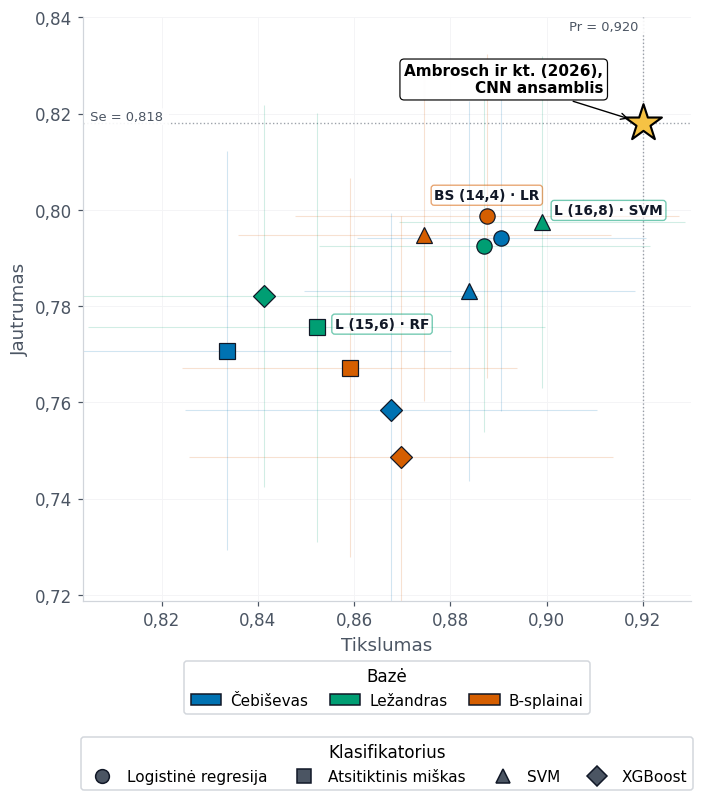

In [28]:
# Operacijos taškas: "f1" (F1-optimuotas slenkstis) arba "youden" (Judeno slenkstis J).
THRESH = "f1"
assert THRESH in ("f1", "youden")
SENS_COL = f"sensitivity_{THRESH}"
PREC_COL = f"precision_{THRESH}"
THRESH_LABEL = THRESH_LT[THRESH]

from matplotlib.transforms import blended_transform_factory

# Vietinis didelio kontrasto bazių rinkinys (Okabe–Ito): aiškiai atskiri tonai
# ekrane ir spalvinio aklumo atveju; oranžinė bazės spalva sąmoningai skiriasi
# nuo auksinės Ambrosch žvaigždutės, kad atskaitos taškas neišnyktų cluster'yje.
FIG15_BASIS_COLORS = {
    "chebyshev": "#0072B2",
    "legendre":  "#009E73",
    "bspline":   "#D55E00",
}
# Ambrosch ir kt. (2026) CNN ansamblis prie F1-optimuoto slenksčio
# (straipsnyje pateikti Se = 0,818, Sp = 0,985, Pr = 0,920). Šios reikšmės
# turi atitikti THRESH = "f1" — kitaip lygintume modelius prie skirtingų
# operacijos taškų.
CNN_PREC, CNN_SENS = 0.920, 0.818
CNN_STAR_COLOR = "#f6c244"

agg15 = (
    df.groupby(["basis", "classifier", "K_BP", "K_RP"])
    .agg(
        pr_auc_mean=("pr_auc", "mean"),
        sens_mean=(SENS_COL, "mean"),
        sens_std=(SENS_COL, "std"),
        prec_mean=(PREC_COL, "mean"),
        prec_std=(PREC_COL, "std"),
    )
    .reset_index()
)

# 12 optimaliausi (basis × classifier) deriniai — tas pats rinkinys kaip 6 lentelėje
best_keys = BEST_CELL.reset_index()[["basis", "classifier", "K_BP", "K_RP"]]
best15 = best_keys.merge(
    agg15, on=["basis", "classifier", "K_BP", "K_RP"], how="left"
).sort_values("pr_auc_mean", ascending=False).reset_index(drop=True)

# Tik trys „istorijos" taškai gauna teksto etiketes; likę 9 atpažįstami iš
# spalvos+žymeklio legendoje. Tai mažina vizualinį triukšmą ir centrinio
# klasterio etikečių persidengimą.
def _pick_one(df_, basis, classifier):
    sub = df_[(df_["basis"] == basis) & (df_["classifier"] == classifier)]
    return sub.iloc[0] if not sub.empty else None

_bs_lr   = _pick_one(best15, "bspline", "LR")     # kompaktiškas čempionas
_l_svm   = _pick_one(best15, "legendre", "SVM")   # globalus geriausias
_trees   = best15[best15["classifier"].isin(["RF", "XGB"])]
_tree_rep = (_trees.sort_values("pr_auc_mean", ascending=False).iloc[0]
             if not _trees.empty else None)

highlight_rows = [r for r in (_bs_lr, _l_svm, _tree_rep) if r is not None]
highlight_keys = {
    (r["basis"], r["classifier"], int(r["K_BP"]), int(r["K_RP"]))
    for r in highlight_rows
}

# Etikečių pozicijos pasirinktos rankiniu būdu, kad nesileistų ant savo žymeklio
# ir nesusiremtų su Ambrosch callout'u. Raktas: (basis, classifier).
# Numatytoji pozicija „dešinė-viršus" naudojama, jei kitas tree_rep būtų išrinktas.
HIGHLIGHT_LABEL_LAYOUT = {
    # ("bspline",  "LR"):  dict(dx=0,  dy=9,  ha="center", va="bottom"),
    # ("legendre", "SVM"): dict(dx=12, dy=7,  ha="left",   va="bottom"),
    ("bspline",  "LR"):  dict(dx=0,  dy=9,  ha="center", va="bottom"),
    ("legendre", "SVM"): dict(dx=8, dy=3,  ha="left",   va="bottom"),
    ("legendre", "RF"):  dict(dx=12, dy=2,  ha="left",   va="center"),
}
_DEFAULT_LAYOUT = dict(dx=14, dy=0, ha="left", va="center")

fig15, ax15 = plt.subplots(figsize=(7.2, 7.6))

# Atskaitos linijos brėžiamos pirmiausia, kad liktų po taškais.
ax15.axvline(CNN_PREC, color=ps.TEXT_MUTED, linestyle=":",
             linewidth=0.9, alpha=0.55, zorder=1)
ax15.axhline(CNN_SENS, color=ps.TEXT_MUTED, linestyle=":",
             linewidth=0.9, alpha=0.55, zorder=1)

# Visi 12 taškų: stiprus žymeklis + labai silpnos klaidų juostos (be cap'ų),
# kad sklaida liktų matoma, bet nedominuotų vaizdo.
for _, r in best15.iterrows():
    color = FIG15_BASIS_COLORS[r["basis"]]
    ax15.errorbar(
        r["prec_mean"], r["sens_mean"],
        xerr=r["prec_std"], yerr=r["sens_std"],
        fmt="none",
        ecolor=color, elinewidth=0.7, capsize=0,
        alpha=0.18, zorder=2,
    )
    ax15.plot(
        r["prec_mean"], r["sens_mean"],
        marker=CLASSIFIER_MARKERS[r["classifier"]],
        markerfacecolor=color, markeredgecolor=ps.TEXT_DARK,
        markeredgewidth=0.8, markersize=10, linestyle="None",
        zorder=4,
    )

# Pažymime tik tris istorinius taškus. Bbox alpha = 0,55 — pakankamai
# permatomas, kad po juo matytųsi gridas ir kaimyninės klaidų juostos.
for r in highlight_rows:
    layout = HIGHLIGHT_LABEL_LAYOUT.get(
        (r["basis"], r["classifier"]), _DEFAULT_LAYOUT
    )
    ax15.annotate(
        f"{BASIS_SHORT[r['basis']]} ({int(r['K_BP'])},{int(r['K_RP'])}) · {r['classifier']}",
        xy=(r["prec_mean"], r["sens_mean"]),
        xytext=(layout["dx"], layout["dy"]), textcoords="offset points",
        fontsize=9, color=ps.TEXT_DARK, fontweight="bold",
        ha=layout["ha"], va=layout["va"],
        bbox=dict(boxstyle="round,pad=0.22", fc="white",
                  ec=FIG15_BASIS_COLORS[r["basis"]],
                  alpha=0.55, linewidth=0.9),
        zorder=5,
    )

# Ambrosch CNN — didelis auksinis žvaigždutė su juodu kontūru ir aiškiu callout'u.
ax15.scatter([CNN_PREC], [CNN_SENS], marker="*", s=640,
             facecolor=CNN_STAR_COLOR, edgecolor="black",
             linewidth=1.4, zorder=6)
ax15.annotate(
    "Ambrosch ir kt. (2026),\nCNN ansamblis",
    xy=(CNN_PREC, CNN_SENS),
    xytext=(-26, 18), textcoords="offset points",
    fontsize=10, color="black", fontweight="bold",
    ha="right", va="bottom",
    bbox=dict(boxstyle="round,pad=0.28", fc="white",
              ec="black", alpha=0.97, linewidth=0.8),
    arrowprops=dict(arrowstyle="->", color="black",
                    lw=0.9, shrinkA=2, shrinkB=10),
    zorder=7,
)

# Skaitinės atskaitos linijų reikšmės — Lietuviškas kablelis, prie ašių kraštų.
trans_h = blended_transform_factory(ax15.transAxes, ax15.transData)
trans_v = blended_transform_factory(ax15.transData, ax15.transAxes)
ax15.text(
    0.005, CNN_SENS, f" Se = {lt_format(CNN_SENS, 3)} ",
    transform=trans_h, ha="left", va="bottom",
    fontsize=8.5, color=ps.TEXT_MUTED,
    bbox=dict(boxstyle="round,pad=0.14", fc="white",
              ec="none", alpha=0.9),
    zorder=3,
)
ax15.text(
    CNN_PREC, 0.995, f" Pr = {lt_format(CNN_PREC, 3)} ",
    transform=trans_v, ha="right", va="top",
    fontsize=8.5, color=ps.TEXT_MUTED,
    bbox=dict(boxstyle="round,pad=0.14", fc="white",
              ec="none", alpha=0.9),
    zorder=3,
)

# Fiksuotos ribos: ymax = 0,86 ir xmax = 0,93 — pakankamai vietos CNN
# žvaigždutei (0,920, 0,818) ir callout'ui, be tuščių sričių.
xmin = min(best15["prec_mean"].min() - 0.03, CNN_PREC - 0.02)
ymin = min(best15["sens_mean"].min() - 0.03, CNN_SENS - 0.02)
ax15.set_xlim(xmin, 0.93)
ax15.set_ylim(ymin, 0.84)

# 1 vienetas tikslumo = 1 vienetas jautrumo vizualiai — kitaip x ašis atrodo
# ~2 kartus „ištempta" lyginant su y, ir trade-off skaitomas klaidingai.
ax15.set_aspect("equal", adjustable="box")

ax15.set_xlabel("Tikslumas", fontsize=12, color=ps.TEXT_MUTED)
ax15.set_ylabel("Jautrumas", fontsize=12, color=ps.TEXT_MUTED)
ps.apply_style(ax15, grid_axis="both")
ax15.xaxis.set_major_formatter(ps.lt_comma_formatter(decimals=2))
ax15.yaxis.set_major_formatter(ps.lt_comma_formatter(decimals=2))

# Trumpos etiketės šio paveikslo legendai — pilni vardai (BASES_LT) būtų
# perdaug platūs ir kerptų legendos rėmą.
FIG15_BASIS_LABELS = {
    "chebyshev": "\u010cebi\u0161evas",
    "legendre":  "Le\u017eandras",
    "bspline":   "B-splainai",
}
basis_handles = [
    Patch(facecolor=FIG15_BASIS_COLORS[b], edgecolor=ps.TEXT_DARK,
          label=FIG15_BASIS_LABELS[b])
    for b in BASES
]
clf_handles = [
    Line2D([0], [0], marker=CLASSIFIER_MARKERS[c], color="w",
           markerfacecolor=ps.TEXT_MUTED, markeredgecolor=ps.TEXT_DARK,
           markersize=9, label=CLASSIFIERS_LT[c])
    for c in CLASSIFIERS if c in df["classifier"].unique()
]

# Su set_aspect("equal") ašių pločio nepakanka, kad abi legendos tilptų į
# vieną eilutę — todėl stackinam vertikaliai, centruotai po grafiku.
leg1 = ax15.legend(handles=basis_handles, loc="upper center",
                   bbox_to_anchor=(0.5, -0.09), ncol=3, title="Bazė",
                   frameon=True, framealpha=0.95, edgecolor=ps.AXIS_GRAY,
                   handletextpad=0.6, columnspacing=1.4)
leg2 = ax15.legend(handles=clf_handles, loc="upper center",
                   bbox_to_anchor=(0.5, -0.22), ncol=4, title="Klasifikatorius",
                   frameon=True, framealpha=0.95, edgecolor=ps.AXIS_GRAY,
                   handletextpad=0.6, columnspacing=1.4)
ax15.add_artist(leg1)

fig15.tight_layout()
fig15.subplots_adjust(bottom=0.28)
save_figure(fig15, "figure15")
plt.show()


## 6. 16 paveikslas — Judeno vs F1 slenksčio palyginimas

Globaliai geriausioje konfigūracijoje (arba, esant `TOP_N_FIG16 > 1`, taip pat ir reitinguose 2–3) lyginamos keturių metrikų reikšmės prie dviejų skirtingų slenksčio politikų: **Judeno-J** (maksimizuoja jautrumas + specifiškumas − 1) ir **F1-optimuotas**. Sugrupuotas stulpelinis grafikas: pagal x — keturios metrikų grupės, pagal grupę — dvi spalvotos stulpelio reikšmės. Virš kiekvieno stulpelio yra konkrečios skaitinės reikšmės.


  Konfigūracija: Ležandro daugianariai / SVM, $K_{BP}=16$, $K_{RP}=8$, PR-AUC = 0,885


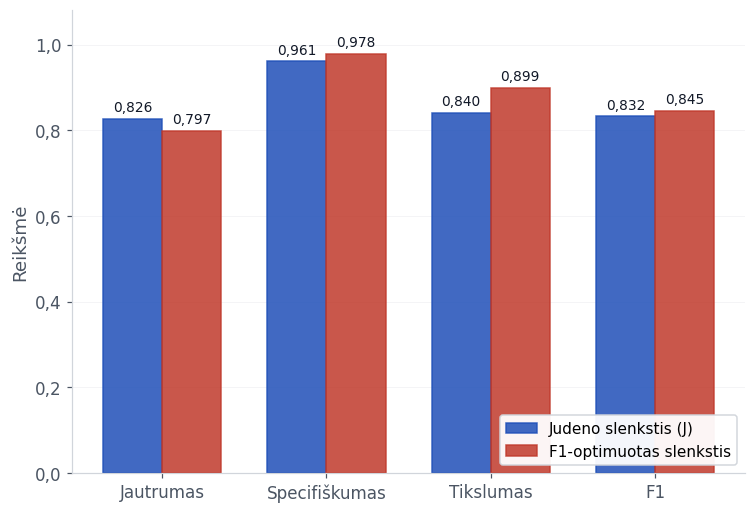

In [14]:
TOP_N_FIG16 = 1  # padidinkite iki 3, jei norite top-3 konfigūracijų

candidates16 = BEST_CELL.reset_index().sort_values("pr_auc", ascending=False)
top_configs16 = list(candidates16.head(TOP_N_FIG16).itertuples(index=False))

metric_keys   = ["sensitivity", "specificity", "precision", "f1"]
metric_labels = ["Jautrumas", "Specifi\u0161kumas", "Tikslumas", "F1"]

fig16, axes16 = plt.subplots(
    1, TOP_N_FIG16, figsize=(7.0 * TOP_N_FIG16, 4.8), squeeze=False,
)

for i, rec in enumerate(top_configs16):
    basis, clf, k_bp, k_rp, pr_auc_mean = (
        rec.basis, rec.classifier, int(rec.K_BP), int(rec.K_RP), float(rec.pr_auc),
    )
    cell = df[(df["basis"] == basis) & (df["classifier"] == clf) &
              (df["K_BP"] == k_bp) & (df["K_RP"] == k_rp)]
    youden_vals = [cell[f"{m}_youden"].mean() for m in metric_keys]
    f1_vals     = [cell[f"{m}_f1"].mean()     for m in metric_keys]

    ax = axes16[0, i]
    x = np.arange(len(metric_keys))
    width = 0.36

    b1 = ax.bar(x - width/2, youden_vals, width,
                color=THRESH_COLORS["youden"], alpha=0.85,
                edgecolor=THRESH_COLORS["youden"], linewidth=1.0,
                label=THRESH_LT["youden"])
    b2 = ax.bar(x + width/2, f1_vals, width,
                color=THRESH_COLORS["f1"], alpha=0.85,
                edgecolor=THRESH_COLORS["f1"], linewidth=1.0,
                label=THRESH_LT["f1"])

    ax.bar_label(b1, labels=[lt_format(v) for v in youden_vals],
                 padding=3, fontsize=9, color=ps.TEXT_DARK)
    ax.bar_label(b2, labels=[lt_format(v) for v in f1_vals],
                 padding=3, fontsize=9, color=ps.TEXT_DARK)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=11)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Reik\u0161m\u0117", fontsize=12, color=ps.TEXT_MUTED)
    cfg_line = (
        f"{BASES_LT[basis]} / {CLASSIFIERS_LT[clf]}, "
        f"$K_{{BP}}={k_bp}$, $K_{{RP}}={k_rp}$, PR-AUC = {lt_format(pr_auc_mean, 3)}"
    )
    if TOP_N_FIG16 > 1:
        ax.set_title(cfg_line, fontsize=10, color=ps.TEXT_MUTED,
                     loc="left", pad=6, fontweight="normal")
    else:
        print(f"  Konfigūracija: {cfg_line}")
    ps.apply_style(ax, grid_axis="y")
    ax.yaxis.set_major_formatter(ps.lt_comma_formatter(decimals=1))
    ax.legend(loc="lower right", fontsize=10, frameon=True,
              framealpha=0.95, edgecolor=ps.AXIS_GRAY)

fig16.tight_layout()
save_figure(fig16, "figure16")
plt.show()


## 7. Suvestiniai skaičiai darbui (spausdinami, neišsaugomi)

Ši ląstelė surenka pagrindinius skaičius, kuriuos autorius gali tiesiogiai cituoti 4 skyriaus tekste: globaliai geriausią konfigūraciją, plokščios srities plotį tarp 12 optimumų, Čebiševo–Ležandro skirtumą, paviršiaus glodumą, „siauros juostos“ vėliavą ir $K_{\mathrm{BP}}$ / $K_{\mathrm{RP}}$ asimetriją kiekvienai $(basis, classifier)$ porai.


In [15]:
print("=" * 78)
print("REZULTAT\u0172 SUVESTIN\u0116S SKAI\u010cIAI (autoriui)")
print("=" * 78)

global_best = BEST_CELL.reset_index().sort_values("pr_auc", ascending=False).iloc[0]
g_b, g_c = global_best["basis"], global_best["classifier"]
g_kbp, g_krp = int(global_best["K_BP"]), int(global_best["K_RP"])
g_cell = df[(df["basis"] == g_b) & (df["classifier"] == g_c) &
            (df["K_BP"] == g_kbp) & (df["K_RP"] == g_krp)]

print("\n1. Geriausia konfig\u016bracija:")
print(f"   baz\u0117             : {BASES_LT[g_b]}")
print(f"   klasifikatorius : {CLASSIFIERS_LT[g_c]}")
print(f"   (K_BP, K_RP)    : ({g_kbp}, {g_krp})  ;  n_coef = {g_kbp + g_krp}")
print(f"   PR-AUC          : {lt_format(g_cell['pr_auc'].mean(), 4)} \u00b1 "
      f"{lt_format(g_cell['pr_auc'].std(), 4)}")

plateau_vals = BEST_CELL["pr_auc"].to_numpy()
print(f"\n2. PR-AUC intervalas tarp {len(plateau_vals)} optimum\u0173 (plokscios srities plotis):")
print(f"   min  : {lt_format(plateau_vals.min(), 4)}")
print(f"   max  : {lt_format(plateau_vals.max(), 4)}")
print(f"   plotis: {lt_format(plateau_vals.max() - plateau_vals.min(), 4)}")

print("\n3. |PR-AUC_\u010c \u2212 PR-AUC_L| did\u017eiausias skirtumas (per visas l\u0105steles):")
print(f"   max  : {lt_format(max_diff, 4)}  (riba sutapimui: {lt_format(CHEB_LEG_DIFF_THRESHOLD, 4)})")

print("\n4. Pavir\u0161iaus glodumas — did\u017eiausias |\u0394PR-AUC| tarp gretim\u0173 l\u0105steli\u0173:")
available_clfs_sum = [c for c in CLASSIFIERS if c in df["classifier"].unique()]
for basis in BASES:
    for clf in available_clfs_sum:
        Z, _, _ = surface(basis, clf)
        dh = np.abs(np.diff(Z, axis=1))
        dv = np.abs(np.diff(Z, axis=0))
        max_step = float(np.nanmax(np.concatenate([dh.ravel(), dv.ravel()])))
        print(f"   {BASES_LT[basis]:25s} / {CLASSIFIERS_LT[clf]:22s}: {lt_format(max_step, 4)}")

print(
    f"\n5. Ar visas pavir\u0161ius telpa \u012f PR-AUC juost\u0105 "
    f"< {lt_format(NARROW_BAND_THRESHOLD, 2)} (multikolinearumo "
    f"\u201esiaura juosta\u201c patikra)?"
)
for basis in BASES:
    for clf in available_clfs_sum:
        Z, _, _ = surface(basis, clf)
        rng = float(np.nanmax(Z) - np.nanmin(Z))
        flag = "TAIP" if rng < NARROW_BAND_THRESHOLD else "NE  "
        print(f"   {BASES_LT[basis]:25s} / {CLASSIFIERS_LT[clf]:22s}: range = {lt_format(rng, 4)}  \u2192 {flag}")

print("\n6. Asimetrija: K_BP \u2212 K_RP \u012f kiekvien\u0105 optimumo l\u0105stel\u0119:")
for basis in BASES:
    for clf in available_clfs_sum:
        k_bp, k_rp, _ = BEST_CELL.loc[(basis, clf)]
        diff_k = int(k_bp) - int(k_rp)
        direction = (
            "K_BP > K_RP" if diff_k > 0
            else ("K_BP = K_RP" if diff_k == 0 else "K_RP > K_BP")
        )
        print(
            f"   {BASES_LT[basis]:25s} / {CLASSIFIERS_LT[clf]:22s}: "
            f"K_BP \u2212 K_RP = {diff_k:+d}  ({direction})"
        )

print("\n" + "=" * 78)


REZULTATŲ SUVESTINĖS SKAIČIAI (autoriui)

1. Geriausia konfigūracija:
   bazė             : Ležandro daugianariai
   klasifikatorius : SVM
   (K_BP, K_RP)    : (16, 8)  ;  n_coef = 24
   PR-AUC          : 0,8852 ± 0,0234

2. PR-AUC intervalas tarp 12 optimumų (plokscios srities plotis):
   min  : 0,8583
   max  : 0,8852
   plotis: 0,0269

3. |PR-AUC_Č − PR-AUC_L| didžiausias skirtumas (per visas ląsteles):
   max  : 0,0372  (riba sutapimui: 0,0020)

4. Paviršiaus glodumas — didžiausias |ΔPR-AUC| tarp gretimų ląstelių:
   Čebiševo daugianariai     / Logistinė regresija   : 0,5305
   Čebiševo daugianariai     / Atsitiktinis miškas   : 0,5826
   Čebiševo daugianariai     / SVM                   : 0,5259


   Čebiševo daugianariai     / XGBoost               : 0,5607
   Ležandro daugianariai     / Logistinė regresija   : 0,5297
   Ležandro daugianariai     / Atsitiktinis miškas   : 0,5826
   Ležandro daugianariai     / SVM                   : 0,5259
   Ležandro daugianariai     / XGBoost               : 0,5495
   B-splainai                / Logistinė regresija   : 0,0031
   B-splainai                / Atsitiktinis miškas   : 0,0115
   B-splainai                / SVM                   : 0,0040
   B-splainai                / XGBoost               : 0,0077

5. Ar visas paviršius telpa į PR-AUC juostą < 0,05 (multikolinearumo „siaura juosta“ patikra)?
   Čebiševo daugianariai     / Logistinė regresija   : range = 0,5611  → NE  
   Čebiševo daugianariai     / Atsitiktinis miškas   : range = 0,6005  → NE  
   Čebiševo daugianariai     / SVM                   : range = 0,5616  → NE  


   Čebiševo daugianariai     / XGBoost               : range = 0,5796  → NE  
   Ležandro daugianariai     / Logistinė regresija   : range = 0,5620  → NE  
   Ležandro daugianariai     / Atsitiktinis miškas   : range = 0,6124  → NE  
   Ležandro daugianariai     / SVM                   : range = 0,5650  → NE  
   Ležandro daugianariai     / XGBoost               : range = 0,5725  → NE  
   B-splainai                / Logistinė regresija   : range = 0,0065  → TAIP


   B-splainai                / Atsitiktinis miškas   : range = 0,0357  → TAIP
   B-splainai                / SVM                   : range = 0,0118  → TAIP
   B-splainai                / XGBoost               : range = 0,0180  → TAIP

6. Asimetrija: K_BP − K_RP į kiekvieną optimumo ląstelę:
   Čebiševo daugianariai     / Logistinė regresija   : K_BP − K_RP = -2  (K_RP > K_BP)
   Čebiševo daugianariai     / Atsitiktinis miškas   : K_BP − K_RP = +11  (K_BP > K_RP)
   Čebiševo daugianariai     / SVM                   : K_BP − K_RP = +8  (K_BP > K_RP)
   Čebiševo daugianariai     / XGBoost               : K_BP − K_RP = +13  (K_BP > K_RP)
   Ležandro daugianariai     / Logistinė regresija   : K_BP − K_RP = +0  (K_BP = K_RP)
   Ležandro daugianariai     / Atsitiktinis miškas   : K_BP − K_RP = +9  (K_BP > K_RP)
   Ležandro daugianariai     / SVM                   : K_BP − K_RP = +8  (K_BP > K_RP)
   Ležandro daugianariai     / XGBoost               : K_BP − K_RP = +10  (K_BP > K_RP)
   B-spla